# Tuning y Validación Avanzada - Modelos Restantes

## Objetivo

Notebook **robusto y productivo** para tuning de hiperparámetros de modelos de clasificación pendientes.

### Características:
- ✅ Un solo bloque de código por modelo
- ✅ Manejo robusto de errores
- ✅ Tabla comparativa con hiperparámetros incluidos
- ✅ Pipeline obligatorio sklearn
- ✅ GridSearchCV exhaustivo
- ✅ StratifiedKFold (5 folds)
- ✅ Persistencia automática

---
## 1. Setup Completo

In [40]:
# ============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================================

import pandas as pd
import numpy as np
import time
import traceback
import joblib
import os

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, 
                                     cross_val_score, StratifiedKFold, 
                                     train_test_split)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix, 
                             f1_score, accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score)

from scipy.stats import loguniform

import matplotlib.pyplot as plt
import seaborn as sns
# Configuración de estilo para gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

print("Librerias importadas correctamente\n")

Librerias importadas correctamente



In [41]:
import pandas as pd

# Cargar datos
df = pd.read_pickle('data_limpia.pkl')

# Ver información del dataset
print("Shape del dataset:", df.shape)
print("\n" + "="*80)
print("COLUMNAS DEL DATASET:")
print("="*80)
print(df.columns.tolist())

print("\n" + "="*80)
print("INFORMACIÓN DEL DATASET:")
print("="*80)
print(df.info())

print("\n" + "="*80)
print("PRIMERAS 5 FILAS:")
print("="*80)
print(df.head())

print("\n" + "="*80)
print("TIPOS DE DATOS:")
print("="*80)
print(df.dtypes)

Shape del dataset: (100000, 29)

COLUMNAS DEL DATASET:
['age', 'monthly_inhand_salary', 'num_bank_accounts', 'num_credit_card', 'interest_rate', 'delay_from_due_date', 'num_of_delayed_payment', 'changed_credit_limit', 'num_credit_inquiries', 'outstanding_debt', 'credit_utilization_ratio', 'credit_history_age', 'total_emi_per_month', 'amount_invested_monthly', 'monthly_balance', 'occupation', 'credit_mix', 'payment_of_min_amount', 'payment_behaviour', 'not_specified', 'credit_builder_loan', 'personal_loan', 'debt_consolidation_loan', 'student_loan', 'payday_loan', 'mortgage_loan', 'auto_loan', 'home_equity_loan', 'credit_score']

INFORMACIÓN DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       100000 non-null  float64
 1   monthly_inhand_salary     100000 non-null  float64
 2  

In [42]:
# ============================================================================
# CARGA DE DATOS Y CONFIGURACIÓN INICIAL
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Configuración global
RANDOM_STATE = 42
N_JOBS = -1

# Cargar datos
print("Cargando datos...")
df = pd.read_pickle('data_limpia.pkl')
print(f"Dataset cargado: {df.shape}")

# Separar features y target
X = df.drop('credit_score', axis=1)
y = df['credit_score']

print(f"\nDistribucion de clases:")
print(y.value_counts())

# División train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nDivision de datos:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")

# Estrategia de validación cruzada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ============================================================================
# CONFIGURACIÓN DEL PREPROCESADOR
# ============================================================================

# Identificar columnas categóricas y numéricas
categorical_features = ['occupation', 'credit_mix', 'payment_of_min_amount', 'payment_behaviour']
numeric_features = [col for col in X_train.columns if col not in categorical_features]

print(f"\nConfiguracion de features:")
print(f"  - Numericas: {len(numeric_features)}")
print(f"  - Categoricas: {len(categorical_features)}")

# Transformadores
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Preprocesador combinado
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("\nPreprocesador configurado exitosamente")
print("="*80 + "\n")

Cargando datos...
Dataset cargado: (100000, 29)

Distribucion de clases:
credit_score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

Division de datos:
  X_train: (80000, 28)
  X_test: (20000, 28)
  y_train: (80000,)
  y_test: (20000,)

Configuracion de features:
  - Numericas: 24
  - Categoricas: 4

Preprocesador configurado exitosamente



In [31]:
def print_model_summary(model_name, metrics, best_params, times, cv_scores):
    """
    Muestra un resumen completo del modelo en formato tabla con F1-Score prioritario

    Args:
        model_name: Nombre del modelo
        metrics: Dict con métricas (train_f1, test_f1, train_acc, test_acc, etc.)
        best_params: Dict con mejores hiperparámetros
        times: Dict con tiempos (grid_time, perm_time, total_time)
        cv_scores: Array con scores de cross-validation
    """

    # Calcular overfitting
    overfitting_gap = metrics['train_f1_macro'] - metrics['test_f1_macro']

    print("\n" + "="*100)
    print(f"{'RESUMEN FINAL - ' + model_name.upper():^100}")
    print("="*100)

    # 1. MÉTRICAS PRINCIPALES (F1-Score prioritario)
    print("\n📊 MÉTRICAS DE RENDIMIENTO (F1-Score Prioritario)")
    print("-" * 100)

    # Crear tabla de métricas
    metrics_data = {
        'Métrica': ['F1-Score', 'Accuracy', 'Balanced Accuracy', 'Precision', 'Recall'],
        'Train': [
            f"{metrics['train_f1_macro']:.4f} ({metrics['train_f1_macro']*100:.2f}%)",
            f"{metrics['train_accuracy']:.4f} ({metrics['train_accuracy']*100:.2f}%)",
            f"{metrics['train_balanced_accuracy']:.4f} ({metrics['train_balanced_accuracy']*100:.2f}%)",
            f"{metrics.get('train_precision_macro', 0):.4f}" if 'train_precision_macro' in metrics else "N/A",
            f"{metrics.get('train_recall_macro', 0):.4f}" if 'train_recall_macro' in metrics else "N/A"
        ],
        'Test': [
            f"{metrics['test_f1_macro']:.4f} ({metrics['test_f1_macro']*100:.2f}%)",
            f"{metrics['test_accuracy']:.4f} ({metrics['test_accuracy']*100:.2f}%)",
            f"{metrics['test_balanced_accuracy']:.4f} ({metrics['test_balanced_accuracy']*100:.2f}%)",
            f"{metrics['test_precision_macro']:.4f} ({metrics['test_precision_macro']*100:.2f}%)",
            f"{metrics['test_recall_macro']:.4f} ({metrics['test_recall_macro']*100:.2f}%)"
        ],
        'Diferencia': [
            f"{overfitting_gap:+.4f}",
            f"{metrics['train_accuracy'] - metrics['test_accuracy']:+.4f}",
            f"{metrics['train_balanced_accuracy'] - metrics['test_balanced_accuracy']:+.4f}",
            "-",
            "-"
        ]
    }

    metrics_df = pd.DataFrame(metrics_data)
    print(metrics_df.to_string(index=False))

    # 2. VALIDACIÓN CRUZADA
    print(f"\n\n🎯 VALIDACIÓN CRUZADA (5-Folds)")
    print("-" * 100)
    cv_data = {
        'Métrica': ['F1-Score CV'],
        'Media': [f"{cv_scores.mean():.4f}"],
        'Desv. Est.': [f"{cv_scores.std():.4f}"],
        'Intervalo 95%': [f"{cv_scores.mean():.4f} ± {cv_scores.std()*2:.4f}"],
        'Min': [f"{cv_scores.min():.4f}"],
        'Max': [f"{cv_scores.max():.4f}"]
    }
    cv_df = pd.DataFrame(cv_data)
    print(cv_df.to_string(index=False))

    # 3. ANÁLISIS DE OVERFITTING
    print(f"\n\n⚠️  ANÁLISIS DE OVERFITTING")
    print("-" * 100)
    overfitting_status = "✓ Buen ajuste" if abs(overfitting_gap) < 0.05 else "⚠ Ligero sobreajuste" if abs(overfitting_gap) < 0.10 else "✗ Sobreajuste significativo"

    overfitting_data = {
        'Métrica': ['F1-Score Gap (Train - Test)', 'Estado'],
        'Valor': [f"{overfitting_gap:+.4f} ({abs(overfitting_gap)*100:.2f}%)", overfitting_status]
    }
    overfitting_df = pd.DataFrame(overfitting_data)
    print(overfitting_df.to_string(index=False))

    # 4. MEJORES HIPERPARÁMETROS
    print(f"\n\n⚙️  MEJORES HIPERPARÁMETROS")
    print("-" * 100)
    params_clean = {k.replace('classifier__', ''): v for k, v in best_params.items()}
    params_data = {
        'Parámetro': list(params_clean.keys()),
        'Valor': [str(v) for v in params_clean.values()]
    }
    params_df = pd.DataFrame(params_data)
    print(params_df.to_string(index=False))

    # 5. EFICIENCIA COMPUTACIONAL
    print(f"\n\n⏱️  EFICIENCIA COMPUTACIONAL")
    print("-" * 100)
    time_data = {
        'Etapa': ['Grid/Random Search', 'Permutation Importance', 'Validación Cruzada', 'Total'],
        'Tiempo (s)': [
            f"{times['grid_time']:.2f}",
            f"{times.get('perm_time', 0):.2f}",
            f"{times.get('cv_time', 0):.2f}",
            f"{times['total_time']:.2f}"
        ],
        'Tiempo (min)': [
            f"{times['grid_time']/60:.2f}",
            f"{times.get('perm_time', 0)/60:.2f}",
            f"{times.get('cv_time', 0)/60:.2f}",
            f"{times['total_time']/60:.2f}"
        ]
    }
    time_df = pd.DataFrame(time_data)
    print(time_df.to_string(index=False))

    # 6. RESUMEN EJECUTIVO
    print(f"\n\n📋 RESUMEN EJECUTIVO")
    print("-" * 100)
    print(f"🏆 Modelo: {model_name}")
    print(f"📈 F1-Score Test (Métrica Principal): {metrics['test_f1_macro']:.4f} ({metrics['test_f1_macro']*100:.2f}%)")
    print(f"✓  Validación Cruzada: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"⚠  Gap Train-Test: {overfitting_gap:+.4f} ({overfitting_status})")
    print(f"⏱  Tiempo Total: {times['total_time']/60:.2f} min")

    print("\n" + "="*100)
    print(f"{'✓ ANÁLISIS COMPLETADO - ' + model_name.upper():^100}")
    print("="*100 + "\n")


---
## 4. MODELO 1: Logistic Regression

In [32]:
# ============================================================================
# LOGISTIC REGRESSION - TUNING OPTIMIZADO
# ============================================================================

# ============================================================================
# FUNCIÓN DE EVALUACIÓN Y GUARDADO
# ============================================================================

def evaluate_and_save_model(model, model_name, X_train, X_test, y_train, y_test,
                           best_params, training_time, cv_scores, grid_search):
    """
    Evalua el modelo y guarda resultados en archivo .pkl
    """
    print(f"\n{'='*80}")
    print(f"EVALUANDO MODELO: {model_name}")
    print(f"{'='*80}")
    
    # Predicciones
    print("Generando predicciones...")
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Metricas
    train_f1 = f1_score(y_train, y_pred_train, average='macro')
    test_f1 = f1_score(y_test, y_pred_test, average='macro')
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
    test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)
    
    # Diccionario de resultados
    results = {
        'model': model,
        'model_name': model_name,
        'best_params': best_params,
        'training_time': training_time,
        'cv_scores': {
            'mean': cv_scores.mean(),
            'std': cv_scores.std(),
            'scores': cv_scores
        },
        'metrics': {
            'train_f1_macro': train_f1,
            'test_f1_macro': test_f1,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'train_balanced_accuracy': train_bal_acc,
            'test_balanced_accuracy': test_bal_acc
        },
        'predictions': {
            'y_train_pred': y_pred_train,
            'y_test_pred': y_pred_test
        },
        'confusion_matrix': confusion_matrix(y_test, y_pred_test),
        'classification_report': classification_report(y_test, y_pred_test),
        'grid_search_results': {
            'cv_results': grid_search.cv_results_,
            'best_index': grid_search.best_index_,
            'best_score': grid_search.best_score_
        }
    }
    
    # Mostrar resultados
    print(f"\nMejores hiperparametros:")
    for param, value in best_params.items():
        print(f"  {param}: {value}")
    
    print(f"\nValidacion Cruzada:")
    print(f"  CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    print(f"\nMetricas de Entrenamiento:")
    print(f"  F1-Macro: {train_f1:.4f}")
    print(f"  Accuracy: {train_acc:.4f}")
    print(f"  Balanced Accuracy: {train_bal_acc:.4f}")
    
    print(f"\nMetricas de Prueba:")
    print(f"  F1-Macro: {test_f1:.4f}")
    print(f"  Accuracy: {test_acc:.4f}")
    print(f"  Balanced Accuracy: {test_bal_acc:.4f}")
    
    print(f"\nTiempo de entrenamiento: {training_time:.2f}s ({training_time/60:.2f} min)")
    
    # Guardar resultados
    os.makedirs('tuning_results', exist_ok=True)
    filename = f"tuning_results/{model_name}_results.pkl"
    joblib.dump(results, filename)
    print(f"\nResultados guardados en: {filename}")
    print(f"{'='*80}\n")
    
    return results

print("Funcion evaluate_and_save_model definida correctamente\n")








print("\n" + "="*80)
print("MODELO 1/5: LOGISTIC REGRESSION")
print("="*80)

try:
    from sklearn.model_selection import RandomizedSearchCV
    from scipy.stats import loguniform
    
    # Pipeline
    lr_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,  # Reducido de 2000
            random_state=RANDOM_STATE,
            tol=1e-4,  # Tolerancia para convergencia más rápida
            warm_start=False
        ))
    ])
    
    # Grid optimizado - separar por penalty
    lr_param_grid = [
        # L1 penalty
        {
            'classifier__penalty': ['l1'],
            'classifier__C': [0.01, 0.1, 1, 10, 100],
            'classifier__solver': ['saga'],
            'classifier__class_weight': [None, 'balanced']
        },
        # L2 penalty
        {
            'classifier__penalty': ['l2'],
            'classifier__C': [0.01, 0.1, 1, 10, 100],
            'classifier__solver': ['saga'],
            'classifier__class_weight': [None, 'balanced']
        },
        # ElasticNet penalty (el único que usa l1_ratio)
        {
            'classifier__penalty': ['elasticnet'],
            'classifier__C': [0.1, 1, 10],
            'classifier__solver': ['saga'],
            'classifier__l1_ratio': [0.3, 0.5, 0.7],
            'classifier__class_weight': [None, 'balanced']
        }
    ]
    
    # Total combinaciones: (5*2) + (5*2) + (3*3*2) = 10 + 10 + 18 = 38
    print("\nHiperparametros a optimizar:")
    print("   L1: C=[0.01-100], class_weight=[None, balanced]")
    print("   L2: C=[0.01-100], class_weight=[None, balanced]")
    print("   ElasticNet: C=[0.1-10], l1_ratio=[0.3-0.7], class_weight=[None, balanced]")
    print(f"\nCombinaciones totales: 38 (optimizado)\n")
    
    # GridSearch con configuración mejorada
    lr_grid = GridSearchCV(
        lr_pipeline, 
        lr_param_grid, 
        cv=cv_strategy, 
        scoring='f1_macro', 
        n_jobs=-1,  # Usar todos los cores
        verbose=2,
        pre_dispatch='2*n_jobs',  # Mejor manejo de memoria
        error_score='raise'  # Mostrar errores claramente
    )
    
    print("Iniciando busqueda de hiperparametros...\n")
    start = time.time()
    lr_grid.fit(X_train, y_train)
    t_time = time.time() - start
    
    print(f"\nEntrenamiento completado en {t_time:.2f}s ({t_time/60:.2f} min)")
    print(f"Mejor CV score: {lr_grid.best_score_:.4f}")
    print(f"Mejores parametros: {lr_grid.best_params_}")
    
    # CV adicional con el mejor modelo
    print("\nEvaluacion adicional con validacion cruzada...")
    lr_cv = cross_val_score(
        lr_grid.best_estimator_, 
        X_train, y_train, 
        cv=cv_strategy, 
        scoring='f1_macro', 
        n_jobs=-1
    )
    
    # Evaluar y guardar
    lr_results = evaluate_and_save_model(
        model=lr_grid.best_estimator_,
        model_name="Logistic_Regression",
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
        best_params=lr_grid.best_params_,
        training_time=t_time,
        cv_scores=lr_cv,
        grid_search=lr_grid
    )
    
    print("Logistic Regression - COMPLETADO")
    
except Exception as e:
    print(f"ERROR en Logistic Regression: {e}")
    traceback.print_exc()
    lr_results = None

Funcion evaluate_and_save_model definida correctamente


MODELO 1/5: LOGISTIC REGRESSION

Hiperparametros a optimizar:
   L1: C=[0.01-100], class_weight=[None, balanced]
   L2: C=[0.01-100], class_weight=[None, balanced]
   ElasticNet: C=[0.1-10], l1_ratio=[0.3-0.7], class_weight=[None, balanced]

Combinaciones totales: 38 (optimizado)

Iniciando busqueda de hiperparametros...

Fitting 5 folds for each of 38 candidates, totalling 190 fits

Entrenamiento completado en 937.69s (15.63 min)
Mejor CV score: 0.6418
Mejores parametros: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}

Evaluacion adicional con validacion cruzada...

EVALUANDO MODELO: Logistic_Regression
Generando predicciones...

Mejores hiperparametros:
  classifier__C: 0.01
  classifier__class_weight: balanced
  classifier__penalty: l1
  classifier__solver: saga

Validacion Cruzada:
  CV Score: 0.6418 (+/- 0.0028)

Metricas de Entrenamiento:
  F1-Macro

---
## 5. MODELO 2: Ridge Classifier

In [ ]:
# ============================================================================
# RIDGE CLASSIFIER - TUNING
# ============================================================================

print("\n" + "="*80)
print("MODELO: RIDGE CLASSIFIER")
print("="*80)

try:
    from sklearn.linear_model import RidgeClassifier
    from sklearn.inspection import permutation_importance
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                                 precision_score, recall_score,
                                 classification_report, confusion_matrix)

    start_time = time.time()

    # Pipeline
    ridge_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RidgeClassifier(
            random_state=RANDOM_STATE,
            tol=1e-4
        ))
    ])

    # Grid de hiperparámetros
    ridge_param_grid = {
        'classifier__alpha': [0.01, 0.1, 1, 10, 100, 1000],
        'classifier__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
        'classifier__class_weight': [None, 'balanced']
    }

    print("\nHiperparametros a optimizar:")
    print("   alpha: [0.01, 0.1, 1, 10, 100, 1000]")
    print("   solver: [auto, svd, cholesky, lsqr, sparse_cg, sag, saga]")
    print("   class_weight: [None, balanced]")
    print(f"\nCombinaciones totales: {6 * 7 * 2} = 84\n")

    # GridSearch
    ridge_grid = GridSearchCV(
        ridge_pipeline,
        ridge_param_grid,
        cv=cv_strategy,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=2,
        pre_dispatch='2*n_jobs',
        error_score='raise',
        return_train_score=True
    )

    print("Iniciando busqueda de hiperparametros...\n")
    grid_start = time.time()
    ridge_grid.fit(X_train, y_train)
    grid_time = time.time() - grid_start

    print(f"\nEntrenamiento completado en {grid_time:.2f}s ({grid_time/60:.2f} min)")
    print(f"Mejor CV score (F1-Macro): {ridge_grid.best_score_:.4f}")
    print(f"Mejores parametros: {ridge_grid.best_params_}")

    # =========================================================================
    # ANÁLISIS DE COMPORTAMIENTO
    # =========================================================================

    print(f"\nANALIZANDO COMPORTAMIENTO DEL MODELO...")

    results_df = pd.DataFrame(ridge_grid.cv_results_)
    train_scores = results_df['mean_train_score']
    test_scores = results_df['mean_test_score']
    gap = train_scores - test_scores

    print(f"\nAnalisis de sobreajuste:")
    print(f"  Diferencia promedio train-test: {gap.mean():.4f}")
    print(f"  Configuraciones probadas: {len(results_df)}")

    # =========================================================================
    # OBTENER FEATURE NAMES DEL PIPELINE ENTRENADO
    # =========================================================================

    print(f"\nOBTENIENDO NOMBRES DE FEATURES...")

    fitted_preprocessor = ridge_grid.best_estimator_.named_steps['preprocessor']
    X_train_transformed = fitted_preprocessor.transform(X_train)
    X_test_transformed = fitted_preprocessor.transform(X_test)
    n_features_actual = X_train_transformed.shape[1]

    print(f"Dimensiones despues del preprocesamiento: {X_train_transformed.shape}")
    print(f"Numero real de features: {n_features_actual}")

    try:
        feature_names = fitted_preprocessor.get_feature_names_out()
        print(f"Feature names obtenidos automaticamente: {len(feature_names)}")
    except:
        feature_names = []
        for name, transformer, columns in fitted_preprocessor.transformers_:
            if name == 'num':
                feature_names.extend([f'num__{col}' for col in columns])
            elif name == 'cat':
                if hasattr(transformer.named_steps['onehot'], 'get_feature_names_out'):
                    cat_features = transformer.named_steps['onehot'].get_feature_names_out(columns)
                    feature_names.extend([f'cat__{feat}' for feat in cat_features])
        print(f"Feature names generados manualmente: {len(feature_names)}")

    if len(feature_names) != n_features_actual:
        print(f"ADVERTENCIA: Ajustando feature_names de {len(feature_names)} a {n_features_actual}")
        if len(feature_names) < n_features_actual:
            feature_names = list(feature_names) + [f'feature_{i}' for i in range(len(feature_names), n_features_actual)]
        else:
            feature_names = list(feature_names)[:n_features_actual]

    print(f"Total de features despues del ajuste: {len(feature_names)}")

    # =========================================================================
    # PERMUTATION IMPORTANCE
    # =========================================================================

    print(f"\nCALCULANDO IMPORTANCIA DE FEATURES...")
    perm_start = time.time()

    perm_result = permutation_importance(
        ridge_grid.best_estimator_,
        X_test,
        y_test,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scoring='f1_macro'
    )

    perm_time = time.time() - perm_start

    print(f"Dimensiones de importancias: {len(perm_result.importances_mean)}")
    print(f"Dimensiones de feature_names: {len(feature_names)}")

    if len(feature_names) != len(perm_result.importances_mean):
        print(f"ADVERTENCIA: Ajustando feature_names de {len(feature_names)} a {len(perm_result.importances_mean)}")
        if len(feature_names) < len(perm_result.importances_mean):
            feature_names = list(feature_names) + [f'feature_{i}' for i in range(len(feature_names), len(perm_result.importances_mean))]
        else:
            feature_names = list(feature_names)[:len(perm_result.importances_mean)]

    perm_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': perm_result.importances_mean,
        'importance_std': perm_result.importances_std
    }).sort_values('importance_mean', ascending=False)

    print(f"Permutation Importance calculado en {perm_time:.2f}s")

    # =========================================================================
    # VALIDACIÓN CRUZADA ADICIONAL
    # =========================================================================

    print("\nEvaluacion adicional con validacion cruzada...")
    cv_start = time.time()
    ridge_cv = cross_val_score(
        ridge_grid.best_estimator_,
        X_train, y_train,
        cv=cv_strategy,
        scoring='f1_macro',
        n_jobs=-1
    )
    cv_time = time.time() - cv_start

    # =========================================================================
    # PREDICCIONES Y MÉTRICAS
    # =========================================================================

    print("Generando predicciones...")
    y_pred_train = ridge_grid.best_estimator_.predict(X_train)
    y_pred_test = ridge_grid.best_estimator_.predict(X_test)

    # Métricas completas
    train_f1 = f1_score(y_train, y_pred_train, average='macro')
    test_f1 = f1_score(y_test, y_pred_test, average='macro')
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
    test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)
    train_precision = precision_score(y_train, y_pred_train, average='macro')
    test_precision = precision_score(y_test, y_pred_test, average='macro')
    train_recall = recall_score(y_train, y_pred_train, average='macro')
    test_recall = recall_score(y_test, y_pred_test, average='macro')

    # =========================================================================
    # MOSTRAR RESUMEN CON FORMATO ESTANDARIZADO
    # =========================================================================

    end_time = time.time()
    execution_time = end_time - start_time

    # Preparar datos para print_model_summary
    metrics = {
        'train_f1_macro': train_f1,
        'test_f1_macro': test_f1,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'train_balanced_accuracy': train_bal_acc,
        'test_balanced_accuracy': test_bal_acc,
        'train_precision_macro': train_precision,
        'test_precision_macro': test_precision,
        'train_recall_macro': train_recall,
        'test_recall_macro': test_recall
    }

    times = {
        'grid_time': grid_time,
        'perm_time': perm_time,
        'cv_time': cv_time,
        'total_time': execution_time
    }

    # Llamar a la función de resumen
    print_model_summary('Ridge Classifier', metrics, ridge_grid.best_params_, times, ridge_cv)

    # =========================================================================
    # TOP 10 FEATURES MÁS IMPORTANTES
    # =========================================================================

    print("\n📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES")
    print("-" * 100)
    top10_data = {
        'Rank': range(1, 11),
        'Feature': perm_df.head(10)['feature'].values,
        'Importancia': perm_df.head(10)['importance_mean'].values,
        'Desv. Est.': perm_df.head(10)['importance_std'].values
    }
    top10_df = pd.DataFrame(top10_data)
    print(top10_df.to_string(index=False))

    print(f"\n\n📊 REPORTE DE CLASIFICACIÓN DETALLADO")
    print("-" * 100)
    print(classification_report(y_test, y_pred_test))

    # =========================================================================
    # GRÁFICAS
    # =========================================================================

    print("\nGenerando graficas...")

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Ridge Classifier - Análisis Completo', fontsize=16, fontweight='bold')

    # 1. Top 15 Features más importantes
    top_features = perm_df.head(15)
    axes[0, 0].barh(range(len(top_features)), top_features['importance_mean'], color='crimson')
    axes[0, 0].set_yticks(range(len(top_features)))
    axes[0, 0].set_yticklabels(top_features['feature'], fontsize=8)
    axes[0, 0].set_xlabel('Importancia Media (F1-Score)')
    axes[0, 0].set_title('Top 15 Features - Permutation Importance')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(True, alpha=0.3, axis='x')

    # 2. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred_test)
    classes = sorted(y_test.unique())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0, 1],
                xticklabels=classes, yticklabels=classes)
    axes[0, 1].set_title('Matriz de Confusion')
    axes[0, 1].set_ylabel('Real')
    axes[0, 1].set_xlabel('Prediccion')

    # 3. Train vs Test Scores (Overfitting Analysis)
    axes[1, 0].scatter(train_scores, test_scores, alpha=0.5, color='indianred')
    axes[1, 0].plot([train_scores.min(), train_scores.max()],
                    [train_scores.min(), train_scores.max()],
                    'r--', lw=2, label='Linea perfecta')
    axes[1, 0].set_xlabel('Train F1-Score')
    axes[1, 0].set_ylabel('Test F1-Score')
    axes[1, 0].set_title('Analisis de Sobreajuste')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Distribución de scores
    axes[1, 1].hist(test_scores, bins=20, alpha=0.7, label='Test F1-Scores',
                    edgecolor='black', color='crimson')
    axes[1, 1].axvline(ridge_grid.best_score_, color='darkred', linestyle='--',
                       linewidth=2, label=f'Best: {ridge_grid.best_score_:.4f}')
    axes[1, 1].set_xlabel('F1-Score')
    axes[1, 1].set_ylabel('Frecuencia')
    axes[1, 1].set_title('Distribucion de F1-Scores en GridSearch')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()

    # Guardar gráficas
    os.makedirs('tuning_results', exist_ok=True)
    plt.savefig('tuning_results/Ridge_Classifier_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Graficas guardadas en: tuning_results/Ridge_Classifier_analysis.png")
    plt.show()

    # =========================================================================
    # GUARDADO DE RESULTADOS
    # =========================================================================

    ridge_results = {
        'model': ridge_grid.best_estimator_,
        'model_name': 'Ridge_Classifier',
        'best_params': ridge_grid.best_params_,
        'training_time': grid_time,
        'total_time': execution_time,
        'grid_search_results': ridge_grid.cv_results_,
        'permutation_importance': perm_df,
        'feature_names': list(feature_names),
        'cv_scores': {
            'mean': ridge_cv.mean(),
            'std': ridge_cv.std(),
            'scores': ridge_cv
        },
        'metrics': {
            'train_f1_macro': train_f1,
            'test_f1_macro': test_f1,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'train_balanced_accuracy': train_bal_acc,
            'test_balanced_accuracy': test_bal_acc,
            'train_precision_macro': train_precision,
            'test_precision_macro': test_precision,
            'train_recall_macro': train_recall,
            'test_recall_macro': test_recall
        },
        'predictions': {
            'y_train_pred': y_pred_train,
            'y_test_pred': y_pred_test
        },
        'confusion_matrix': cm,
        'classification_report': classification_report(y_test, y_pred_test),
        'overfitting_analysis': {
            'train_test_gap_mean': gap.mean(),
            'train_test_gap_std': gap.std()
        }
    }

    joblib.dump(ridge_results, 'tuning_results/Ridge_Classifier_results.pkl')
    print("✓ Resultados completos guardados: tuning_results/Ridge_Classifier_results.pkl")

    joblib.dump(ridge_grid.best_estimator_, 'tuning_results/best_Ridge_Classifier_model.pkl')
    print("✓ Mejor modelo guardado: tuning_results/best_Ridge_Classifier_model.pkl")

except Exception as e:
    print(f"\nERROR en Ridge Classifier: {e}")
    traceback.print_exc()
    ridge_results = None


In [ ]:
# ============================================================================
# LOGISTIC REGRESSION - TUNING
# ============================================================================

print("\n" + "="*80)
print("MODELO 1/5: LOGISTIC REGRESSION")
print("="*80)

try:
    from sklearn.model_selection import RandomizedSearchCV
    from sklearn.inspection import permutation_importance
    from scipy.stats import loguniform
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                                 precision_score, recall_score,
                                 classification_report, confusion_matrix)

    start_time = time.time()

    # Pipeline
    lr_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            tol=1e-4,
            warm_start=False
        ))
    ])

    # Grid optimizado - separar por penalty
    lr_param_grid = [
        # L1 penalty
        {
            'classifier__penalty': ['l1'],
            'classifier__C': [0.01, 0.1, 1, 10, 100],
            'classifier__solver': ['saga'],
            'classifier__class_weight': [None, 'balanced']
        },
        # L2 penalty
        {
            'classifier__penalty': ['l2'],
            'classifier__C': [0.01, 0.1, 1, 10, 100],
            'classifier__solver': ['saga'],
            'classifier__class_weight': [None, 'balanced']
        },
        # ElasticNet penalty
        {
            'classifier__penalty': ['elasticnet'],
            'classifier__C': [0.1, 1, 10],
            'classifier__solver': ['saga'],
            'classifier__l1_ratio': [0.3, 0.5, 0.7],
            'classifier__class_weight': [None, 'balanced']
        }
    ]

    print("\nHiperparametros a optimizar:")
    print("   L1: C=[0.01-100], class_weight=[None, balanced]")
    print("   L2: C=[0.01-100], class_weight=[None, balanced]")
    print("   ElasticNet: C=[0.1-10], l1_ratio=[0.3-0.7], class_weight=[None, balanced]")
    print(f"\nCombinaciones totales: 38 (optimizado)\n")

    # GridSearch
    lr_grid = GridSearchCV(
        lr_pipeline,
        lr_param_grid,
        cv=cv_strategy,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=2,
        pre_dispatch='2*n_jobs',
        error_score='raise',
        return_train_score=True
    )

    print("Iniciando busqueda de hiperparametros...\n")
    grid_start = time.time()
    lr_grid.fit(X_train, y_train)
    grid_time = time.time() - grid_start

    print(f"\nEntrenamiento completado en {grid_time:.2f}s ({grid_time/60:.2f} min)")
    print(f"Mejor CV score (F1-Macro): {lr_grid.best_score_:.4f}")
    print(f"Mejores parametros: {lr_grid.best_params_}")

    # =========================================================================
    # ANÁLISIS DE COMPORTAMIENTO
    # =========================================================================

    print(f"\nANALIZANDO COMPORTAMIENTO DEL MODELO...")

    results_df = pd.DataFrame(lr_grid.cv_results_)
    train_scores = results_df['mean_train_score']
    test_scores = results_df['mean_test_score']
    gap = train_scores - test_scores

    print(f"\nAnalisis de sobreajuste:")
    print(f"  Diferencia promedio train-test: {gap.mean():.4f}")
    print(f"  Configuraciones probadas: {len(results_df)}")

    # =========================================================================
    # OBTENER FEATURE NAMES DEL PIPELINE ENTRENADO
    # =========================================================================

    print(f"\nOBTENIENDO NOMBRES DE FEATURES...")

    fitted_preprocessor = lr_grid.best_estimator_.named_steps['preprocessor']
    X_train_transformed = fitted_preprocessor.transform(X_train)
    X_test_transformed = fitted_preprocessor.transform(X_test)
    n_features_actual = X_train_transformed.shape[1]

    print(f"Dimensiones despues del preprocesamiento: {X_train_transformed.shape}")
    print(f"Numero real de features: {n_features_actual}")

    try:
        feature_names = fitted_preprocessor.get_feature_names_out()
        print(f"Feature names obtenidos automaticamente: {len(feature_names)}")
    except:
        feature_names = []
        for name, transformer, columns in fitted_preprocessor.transformers_:
            if name == 'num':
                feature_names.extend([f'num__{col}' for col in columns])
            elif name == 'cat':
                if hasattr(transformer.named_steps['onehot'], 'get_feature_names_out'):
                    cat_features = transformer.named_steps['onehot'].get_feature_names_out(columns)
                    feature_names.extend([f'cat__{feat}' for feat in cat_features])
        print(f"Feature names generados manualmente: {len(feature_names)}")

    if len(feature_names) != n_features_actual:
        print(f"ADVERTENCIA: Ajustando feature_names de {len(feature_names)} a {n_features_actual}")
        if len(feature_names) < n_features_actual:
            feature_names = list(feature_names) + [f'feature_{i}' for i in range(len(feature_names), n_features_actual)]
        else:
            feature_names = list(feature_names)[:n_features_actual]

    print(f"Total de features despues del ajuste: {len(feature_names)}")

    # =========================================================================
    # PERMUTATION IMPORTANCE
    # =========================================================================

    print(f"\nCALCULANDO IMPORTANCIA DE FEATURES...")
    perm_start = time.time()

    perm_result = permutation_importance(
        lr_grid.best_estimator_,
        X_test,
        y_test,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scoring='f1_macro'
    )

    perm_time = time.time() - perm_start

    print(f"Dimensiones de importancias: {len(perm_result.importances_mean)}")
    print(f"Dimensiones de feature_names: {len(feature_names)}")

    if len(feature_names) != len(perm_result.importances_mean):
        print(f"ADVERTENCIA: Ajustando feature_names de {len(feature_names)} a {len(perm_result.importances_mean)}")
        if len(feature_names) < len(perm_result.importances_mean):
            feature_names = list(feature_names) + [f'feature_{i}' for i in range(len(feature_names), len(perm_result.importances_mean))]
        else:
            feature_names = list(feature_names)[:len(perm_result.importances_mean)]

    perm_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': perm_result.importances_mean,
        'importance_std': perm_result.importances_std
    }).sort_values('importance_mean', ascending=False)

    print(f"Permutation Importance calculado en {perm_time:.2f}s")

    # =========================================================================
    # VALIDACIÓN CRUZADA ADICIONAL
    # =========================================================================

    print("\nEvaluacion adicional con validacion cruzada...")
    cv_start = time.time()
    lr_cv = cross_val_score(
        lr_grid.best_estimator_,
        X_train, y_train,
        cv=cv_strategy,
        scoring='f1_macro',
        n_jobs=-1
    )
    cv_time = time.time() - cv_start

    # =========================================================================
    # PREDICCIONES Y MÉTRICAS
    # =========================================================================

    print("Generando predicciones...")
    y_pred_train = lr_grid.best_estimator_.predict(X_train)
    y_pred_test = lr_grid.best_estimator_.predict(X_test)

    # Métricas completas
    train_f1 = f1_score(y_train, y_pred_train, average='macro')
    test_f1 = f1_score(y_test, y_pred_test, average='macro')
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
    test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)
    train_precision = precision_score(y_train, y_pred_train, average='macro')
    test_precision = precision_score(y_test, y_pred_test, average='macro')
    train_recall = recall_score(y_train, y_pred_train, average='macro')
    test_recall = recall_score(y_test, y_pred_test, average='macro')

    # =========================================================================
    # MOSTRAR RESUMEN CON FORMATO ESTANDARIZADO
    # =========================================================================

    end_time = time.time()
    execution_time = end_time - start_time

    # Preparar datos para print_model_summary
    metrics = {
        'train_f1_macro': train_f1,
        'test_f1_macro': test_f1,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'train_balanced_accuracy': train_bal_acc,
        'test_balanced_accuracy': test_bal_acc,
        'train_precision_macro': train_precision,
        'test_precision_macro': test_precision,
        'train_recall_macro': train_recall,
        'test_recall_macro': test_recall
    }

    times = {
        'grid_time': grid_time,
        'perm_time': perm_time,
        'cv_time': cv_time,
        'total_time': execution_time
    }

    # Llamar a la función de resumen
    print_model_summary('Logistic Regression', metrics, lr_grid.best_params_, times, lr_cv)

    # =========================================================================
    # TOP 10 FEATURES MÁS IMPORTANTES
    # =========================================================================

    print("\n📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES")
    print("-" * 100)
    top10_data = {
        'Rank': range(1, 11),
        'Feature': perm_df.head(10)['feature'].values,
        'Importancia': perm_df.head(10)['importance_mean'].values,
        'Desv. Est.': perm_df.head(10)['importance_std'].values
    }
    top10_df = pd.DataFrame(top10_data)
    print(top10_df.to_string(index=False))

    print(f"\n\n📊 REPORTE DE CLASIFICACIÓN DETALLADO")
    print("-" * 100)
    print(classification_report(y_test, y_pred_test))

    # =========================================================================
    # GRÁFICAS
    # =========================================================================

    print("\nGenerando graficas...")

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Logistic Regression - Análisis Completo', fontsize=16, fontweight='bold')

    # 1. Top 15 Features más importantes
    top_features = perm_df.head(15)
    axes[0, 0].barh(range(len(top_features)), top_features['importance_mean'])
    axes[0, 0].set_yticks(range(len(top_features)))
    axes[0, 0].set_yticklabels(top_features['feature'], fontsize=8)
    axes[0, 0].set_xlabel('Importancia Media (F1-Score)')
    axes[0, 0].set_title('Top 15 Features - Permutation Importance')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(True, alpha=0.3, axis='x')

    # 2. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred_test)
    classes = sorted(y_test.unique())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
                xticklabels=classes, yticklabels=classes)
    axes[0, 1].set_title('Matriz de Confusion')
    axes[0, 1].set_ylabel('Real')
    axes[0, 1].set_xlabel('Prediccion')

    # 3. Train vs Test Scores (Overfitting Analysis)
    axes[1, 0].scatter(train_scores, test_scores, alpha=0.5)
    axes[1, 0].plot([train_scores.min(), train_scores.max()],
                    [train_scores.min(), train_scores.max()],
                    'r--', lw=2, label='Linea perfecta')
    axes[1, 0].set_xlabel('Train F1-Score')
    axes[1, 0].set_ylabel('Test F1-Score')
    axes[1, 0].set_title('Analisis de Sobreajuste')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Distribución de scores
    axes[1, 1].hist(test_scores, bins=20, alpha=0.7, label='Test F1-Scores',
                    edgecolor='black', color='steelblue')
    axes[1, 1].axvline(lr_grid.best_score_, color='r', linestyle='--',
                       linewidth=2, label=f'Best: {lr_grid.best_score_:.4f}')
    axes[1, 1].set_xlabel('F1-Score')
    axes[1, 1].set_ylabel('Frecuencia')
    axes[1, 1].set_title('Distribucion de F1-Scores en GridSearch')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()

    # Guardar gráficas
    os.makedirs('tuning_results', exist_ok=True)
    plt.savefig('tuning_results/Logistic_Regression_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Graficas guardadas en: tuning_results/Logistic_Regression_analysis.png")
    plt.show()

    # =========================================================================
    # GUARDADO DE RESULTADOS
    # =========================================================================

    lr_results = {
        'model': lr_grid.best_estimator_,
        'model_name': 'Logistic_Regression',
        'best_params': lr_grid.best_params_,
        'training_time': grid_time,
        'total_time': execution_time,
        'grid_search_results': lr_grid.cv_results_,
        'permutation_importance': perm_df,
        'feature_names': list(feature_names),
        'cv_scores': {
            'mean': lr_cv.mean(),
            'std': lr_cv.std(),
            'scores': lr_cv
        },
        'metrics': {
            'train_f1_macro': train_f1,
            'test_f1_macro': test_f1,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'train_balanced_accuracy': train_bal_acc,
            'test_balanced_accuracy': test_bal_acc,
            'train_precision_macro': train_precision,
            'test_precision_macro': test_precision,
            'train_recall_macro': train_recall,
            'test_recall_macro': test_recall
        },
        'predictions': {
            'y_train_pred': y_pred_train,
            'y_test_pred': y_pred_test
        },
        'confusion_matrix': cm,
        'classification_report': classification_report(y_test, y_pred_test),
        'overfitting_analysis': {
            'train_test_gap_mean': gap.mean(),
            'train_test_gap_std': gap.std()
        }
    }

    joblib.dump(lr_results, 'tuning_results/Logistic_Regression_results.pkl')
    print("✓ Resultados completos guardados: tuning_results/Logistic_Regression_results.pkl")

    joblib.dump(lr_grid.best_estimator_, 'tuning_results/best_Logistic_Regression_model.pkl')
    print("✓ Mejor modelo guardado: tuning_results/best_Logistic_Regression_model.pkl")

except Exception as e:
    print(f"\nERROR en Logistic Regression: {e}")
    traceback.print_exc()
    lr_results = None


---
## 6. MODELO 3: Decision Tree

In [ ]:
# ============================================================================
# DECISION TREE - TUNING
# ============================================================================

print("\n" + "="*80)
print("MODELO: DECISION TREE")
print("="*80)

try:
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.model_selection import RandomizedSearchCV
    from sklearn.inspection import permutation_importance
    from scipy.stats import randint, uniform
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                                 precision_score, recall_score,
                                 classification_report, confusion_matrix)
    import numpy as np

    start_time = time.time()

    # Pipeline
    dt_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ))
    ])

    # Distribuciones de hiperparámetros para RandomizedSearchCV
    dt_param_distributions = {
        'classifier__criterion': ['gini', 'entropy', 'log_loss'],
        'classifier__max_depth': [None, 5, 10, 15, 20, 25, 30, 40, 50],
        'classifier__min_samples_split': randint(2, 50),
        'classifier__min_samples_leaf': randint(1, 30),
        'classifier__max_features': [None, 'sqrt', 'log2', 0.5, 0.7, 0.9],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__splitter': ['best', 'random'],
        'classifier__min_impurity_decrease': uniform(0.0, 0.01)
    }

    print("\nHiperparametros a optimizar:")
    print("   criterion: [gini, entropy, log_loss]")
    print("   max_depth: [None, 5, 10, 15, 20, 25, 30, 40, 50]")
    print("   min_samples_split: randint(2, 50)")
    print("   min_samples_leaf: randint(1, 30)")
    print("   max_features: [None, sqrt, log2, 0.5, 0.7, 0.9]")
    print("   class_weight: [None, balanced]")
    print("   splitter: [best, random]")
    print("   min_impurity_decrease: uniform(0.0, 0.01)")
    print(f"\nIteraciones de RandomizedSearchCV: 100\n")

    # RandomizedSearchCV
    dt_grid = RandomizedSearchCV(
        dt_pipeline,
        dt_param_distributions,
        n_iter=100,
        cv=cv_strategy,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=2,
        random_state=RANDOM_STATE,
        pre_dispatch='2*n_jobs',
        error_score='raise',
        return_train_score=True
    )

    print("Iniciando busqueda de hiperparametros...\n")
    grid_start = time.time()
    dt_grid.fit(X_train, y_train)
    grid_time = time.time() - grid_start

    print(f"\nEntrenamiento completado en {grid_time:.2f}s ({grid_time/60:.2f} min)")
    print(f"Mejor CV score (F1-Macro): {dt_grid.best_score_:.4f}")
    print(f"Mejores parametros: {dt_grid.best_params_}")

    # =========================================================================
    # ANÁLISIS DE COMPORTAMIENTO
    # =========================================================================

    print(f"\nANALIZANDO COMPORTAMIENTO DEL MODELO...")

    results_df = pd.DataFrame(dt_grid.cv_results_)
    train_scores = results_df['mean_train_score']
    test_scores = results_df['mean_test_score']
    gap = train_scores - test_scores

    print(f"\nAnalisis de sobreajuste:")
    print(f"  Diferencia promedio train-test: {gap.mean():.4f}")
    print(f"  Configuraciones probadas: {len(results_df)}")

    # =========================================================================
    # OBTENER FEATURE NAMES DEL PIPELINE ENTRENADO
    # =========================================================================

    print(f"\nOBTENIENDO NOMBRES DE FEATURES...")

    fitted_preprocessor = dt_grid.best_estimator_.named_steps['preprocessor']
    X_train_transformed = fitted_preprocessor.transform(X_train)
    X_test_transformed = fitted_preprocessor.transform(X_test)
    n_features_actual = X_train_transformed.shape[1]

    print(f"Dimensiones despues del preprocesamiento: {X_train_transformed.shape}")
    print(f"Numero real de features: {n_features_actual}")

    try:
        feature_names = fitted_preprocessor.get_feature_names_out()
        print(f"Feature names obtenidos automaticamente: {len(feature_names)}")
    except:
        feature_names = []
        for name, transformer, columns in fitted_preprocessor.transformers_:
            if name == 'num':
                feature_names.extend([f'num__{col}' for col in columns])
            elif name == 'cat':
                if hasattr(transformer.named_steps['onehot'], 'get_feature_names_out'):
                    cat_features = transformer.named_steps['onehot'].get_feature_names_out(columns)
                    feature_names.extend([f'cat__{feat}' for feat in cat_features])
        print(f"Feature names generados manualmente: {len(feature_names)}")

    if len(feature_names) != n_features_actual:
        print(f"ADVERTENCIA: Ajustando feature_names de {len(feature_names)} a {n_features_actual}")
        if len(feature_names) < n_features_actual:
            feature_names = list(feature_names) + [f'feature_{i}' for i in range(len(feature_names), n_features_actual)]
        else:
            feature_names = list(feature_names)[:n_features_actual]

    print(f"Total de features despues del ajuste: {len(feature_names)}")

    # =========================================================================
    # NATIVE FEATURE IMPORTANCE (Decision Tree)
    # =========================================================================

    print(f"\nOBTENIENDO IMPORTANCIA NATIVA DE FEATURES (Decision Tree)...")
    best_dt_classifier = dt_grid.best_estimator_.named_steps['classifier']
    native_importances = best_dt_classifier.feature_importances_

    native_df = pd.DataFrame({
        'feature': feature_names,
        'importance': native_importances
    }).sort_values('importance', ascending=False)

    print(f"Native Feature Importance calculado")

    # =========================================================================
    # PERMUTATION IMPORTANCE
    # =========================================================================

    print(f"\nCALCULANDO IMPORTANCIA DE FEATURES (Permutation)...")
    perm_start = time.time()

    perm_result = permutation_importance(
        dt_grid.best_estimator_,
        X_test,
        y_test,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scoring='f1_macro'
    )

    perm_time = time.time() - perm_start

    print(f"Dimensiones de importancias: {len(perm_result.importances_mean)}")
    print(f"Dimensiones de feature_names: {len(feature_names)}")

    if len(feature_names) != len(perm_result.importances_mean):
        print(f"ADVERTENCIA: Ajustando feature_names de {len(feature_names)} a {len(perm_result.importances_mean)}")
        if len(feature_names) < len(perm_result.importances_mean):
            feature_names = list(feature_names) + [f'feature_{i}' for i in range(len(feature_names), len(perm_result.importances_mean))]
        else:
            feature_names = list(feature_names)[:len(perm_result.importances_mean)]

    perm_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': perm_result.importances_mean,
        'importance_std': perm_result.importances_std
    }).sort_values('importance_mean', ascending=False)

    print(f"Permutation Importance calculado en {perm_time:.2f}s")

    # =========================================================================
    # DEPTH VS PERFORMANCE ANALYSIS
    # =========================================================================

    print(f"\nANALIZANDO PROFUNDIDAD VS PERFORMANCE...")
    depth_analysis = results_df[['param_classifier__max_depth', 'mean_test_score', 'mean_train_score']].copy()
    depth_analysis['param_classifier__max_depth'] = depth_analysis['param_classifier__max_depth'].fillna('None')
    depth_grouped = depth_analysis.groupby('param_classifier__max_depth').agg({
        'mean_test_score': 'mean',
        'mean_train_score': 'mean'
    }).reset_index()

    # =========================================================================
    # VALIDACIÓN CRUZADA ADICIONAL
    # =========================================================================

    print("\nEvaluacion adicional con validacion cruzada...")
    cv_start = time.time()
    dt_cv = cross_val_score(
        dt_grid.best_estimator_,
        X_train, y_train,
        cv=cv_strategy,
        scoring='f1_macro',
        n_jobs=-1
    )
    cv_time = time.time() - cv_start

    # =========================================================================
    # PREDICCIONES Y MÉTRICAS
    # =========================================================================

    print("Generando predicciones...")
    y_pred_train = dt_grid.best_estimator_.predict(X_train)
    y_pred_test = dt_grid.best_estimator_.predict(X_test)

    # Métricas completas
    train_f1 = f1_score(y_train, y_pred_train, average='macro')
    test_f1 = f1_score(y_test, y_pred_test, average='macro')
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
    test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)
    train_precision = precision_score(y_train, y_pred_train, average='macro')
    test_precision = precision_score(y_test, y_pred_test, average='macro')
    train_recall = recall_score(y_train, y_pred_train, average='macro')
    test_recall = recall_score(y_test, y_pred_test, average='macro')

    # =========================================================================
    # MOSTRAR RESUMEN CON FORMATO ESTANDARIZADO
    # =========================================================================

    end_time = time.time()
    execution_time = end_time - start_time

    # Preparar datos para print_model_summary
    metrics = {
        'train_f1_macro': train_f1,
        'test_f1_macro': test_f1,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'train_balanced_accuracy': train_bal_acc,
        'test_balanced_accuracy': test_bal_acc,
        'train_precision_macro': train_precision,
        'test_precision_macro': test_precision,
        'train_recall_macro': train_recall,
        'test_recall_macro': test_recall
    }

    times = {
        'grid_time': grid_time,
        'perm_time': perm_time,
        'cv_time': cv_time,
        'total_time': execution_time
    }

    # Llamar a la función de resumen
    print_model_summary('Decision Tree', metrics, dt_grid.best_params_, times, dt_cv)

    # =========================================================================
    # TOP 10 FEATURES MÁS IMPORTANTES
    # =========================================================================

    print("\n📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES")
    print("-" * 100)
    top10_data = {
        'Rank': range(1, 11),
        'Feature': perm_df.head(10)['feature'].values,
        'Importancia': perm_df.head(10)['importance_mean'].values,
        'Desv. Est.': perm_df.head(10)['importance_std'].values
    }
    top10_df = pd.DataFrame(top10_data)
    print(top10_df.to_string(index=False))

    print(f"\n\n📊 REPORTE DE CLASIFICACIÓN DETALLADO")
    print("-" * 100)
    print(classification_report(y_test, y_pred_test))

    # =========================================================================
    # GRÁFICAS (3x2 layout)
    # =========================================================================

    print("\nGenerando graficas...")

    fig, axes = plt.subplots(3, 2, figsize=(15, 18))
    fig.suptitle('Decision Tree - Análisis Completo', fontsize=16, fontweight='bold')

    # 1. Top 15 Features - Permutation Importance
    top_features = perm_df.head(15)
    axes[0, 0].barh(range(len(top_features)), top_features['importance_mean'], color='forestgreen')
    axes[0, 0].set_yticks(range(len(top_features)))
    axes[0, 0].set_yticklabels(top_features['feature'], fontsize=8)
    axes[0, 0].set_xlabel('Importancia Media (F1-Score)')
    axes[0, 0].set_title('Top 15 Features - Permutation Importance')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(True, alpha=0.3, axis='x')

    # 2. Native Feature Importance (Decision Tree)
    top_native = native_df.head(15)
    axes[0, 1].barh(range(len(top_native)), top_native['importance'], color='darkorange')
    axes[0, 1].set_yticks(range(len(top_native)))
    axes[0, 1].set_yticklabels(top_native['feature'], fontsize=8)
    axes[0, 1].set_xlabel('Importancia (Gini/Entropy)')
    axes[0, 1].set_title('Top 15 Features - Native Feature Importance')
    axes[0, 1].invert_yaxis()
    axes[0, 1].grid(True, alpha=0.3, axis='x')

    # 3. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred_test)
    classes = sorted(y_test.unique())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1, 0],
                xticklabels=classes, yticklabels=classes)
    axes[1, 0].set_title('Matriz de Confusion')
    axes[1, 0].set_ylabel('Real')
    axes[1, 0].set_xlabel('Prediccion')

    # 4. Depth vs Performance
    # Convertir 'None' a un valor numérico para graficar
    depth_plot = depth_grouped.copy()
    depth_plot['depth_numeric'] = depth_plot['param_classifier__max_depth'].apply(
        lambda x: 100 if x == 'None' else int(x)
    )
    depth_plot = depth_plot.sort_values('depth_numeric')

    axes[1, 1].plot(depth_plot['depth_numeric'], depth_plot['mean_train_score'],
                    marker='o', label='Train F1-Score', color='forestgreen', linewidth=2)
    axes[1, 1].plot(depth_plot['depth_numeric'], depth_plot['mean_test_score'],
                    marker='s', label='Test F1-Score', color='darkorange', linewidth=2)
    axes[1, 1].set_xlabel('Max Depth (100 = None)')
    axes[1, 1].set_ylabel('F1-Score')
    axes[1, 1].set_title('Profundidad vs Performance')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # 5. Train vs Test Scores (Overfitting Analysis)
    axes[2, 0].scatter(train_scores, test_scores, alpha=0.5, color='forestgreen')
    axes[2, 0].plot([train_scores.min(), train_scores.max()],
                    [train_scores.min(), train_scores.max()],
                    'r--', lw=2, label='Linea perfecta')
    axes[2, 0].set_xlabel('Train F1-Score')
    axes[2, 0].set_ylabel('Test F1-Score')
    axes[2, 0].set_title('Analisis de Sobreajuste')
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)

    # 6. Distribución de scores
    axes[2, 1].hist(test_scores, bins=20, alpha=0.7, label='Test F1-Scores',
                    edgecolor='black', color='forestgreen')
    axes[2, 1].axvline(dt_grid.best_score_, color='darkgreen', linestyle='--',
                       linewidth=2, label=f'Best: {dt_grid.best_score_:.4f}')
    axes[2, 1].set_xlabel('F1-Score')
    axes[2, 1].set_ylabel('Frecuencia')
    axes[2, 1].set_title('Distribucion de F1-Scores en RandomizedSearchCV')
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)

    plt.tight_layout()

    # Guardar gráficas
    os.makedirs('tuning_results', exist_ok=True)
    plt.savefig('tuning_results/Decision_Tree_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Graficas guardadas en: tuning_results/Decision_Tree_analysis.png")
    plt.show()

    # =========================================================================
    # GUARDADO DE RESULTADOS
    # =========================================================================

    dt_results = {
        'model': dt_grid.best_estimator_,
        'model_name': 'Decision_Tree',
        'best_params': dt_grid.best_params_,
        'training_time': grid_time,
        'total_time': execution_time,
        'grid_search_results': dt_grid.cv_results_,
        'permutation_importance': perm_df,
        'native_importance': native_df,
        'depth_analysis': depth_grouped,
        'feature_names': list(feature_names),
        'cv_scores': {
            'mean': dt_cv.mean(),
            'std': dt_cv.std(),
            'scores': dt_cv
        },
        'metrics': {
            'train_f1_macro': train_f1,
            'test_f1_macro': test_f1,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'train_balanced_accuracy': train_bal_acc,
            'test_balanced_accuracy': test_bal_acc,
            'train_precision_macro': train_precision,
            'test_precision_macro': test_precision,
            'train_recall_macro': train_recall,
            'test_recall_macro': test_recall
        },
        'predictions': {
            'y_train_pred': y_pred_train,
            'y_test_pred': y_pred_test
        },
        'confusion_matrix': cm,
        'classification_report': classification_report(y_test, y_pred_test),
        'overfitting_analysis': {
            'train_test_gap_mean': gap.mean(),
            'train_test_gap_std': gap.std()
        }
    }

    joblib.dump(dt_results, 'tuning_results/Decision_Tree_results.pkl')
    print("✓ Resultados completos guardados: tuning_results/Decision_Tree_results.pkl")

    joblib.dump(dt_grid.best_estimator_, 'tuning_results/best_Decision_Tree_model.pkl')
    print("✓ Mejor modelo guardado: tuning_results/best_Decision_Tree_model.pkl")

except Exception as e:
    print(f"\nERROR en Decision Tree: {e}")
    traceback.print_exc()
    dt_results = None


---
## 7. MODELO 4: Gaussian Naive Bayes

In [ ]:
# ============================================================================
# GAUSSIAN NAIVE BAYES - TUNING
# ============================================================================

print("\n" + "="*80)
print("MODELO: GAUSSIAN NAIVE BAYES")
print("="*80)

try:
    from sklearn.naive_bayes import GaussianNB
    from sklearn.inspection import permutation_importance
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                                 precision_score, recall_score,
                                 classification_report, confusion_matrix)
    import numpy as np

    start_time = time.time()

    # Pipeline
    nb_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GaussianNB())
    ])

    # Grid de hiperparámetros
    nb_param_grid = {
        'classifier__var_smoothing': np.logspace(-12, -3, 30)
    }

    print("\nHiperparametros a optimizar:")
    print("   var_smoothing: np.logspace(-12, -3, 30)")
    print(f"\nCombinaciones totales: 30\n")

    # GridSearch
    nb_grid = GridSearchCV(
        nb_pipeline,
        nb_param_grid,
        cv=cv_strategy,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=2,
        pre_dispatch='2*n_jobs',
        error_score='raise',
        return_train_score=True
    )

    print("Iniciando busqueda de hiperparametros...\n")
    grid_start = time.time()
    nb_grid.fit(X_train, y_train)
    grid_time = time.time() - grid_start

    print(f"\nEntrenamiento completado en {grid_time:.2f}s ({grid_time/60:.2f} min)")
    print(f"Mejor CV score (F1-Macro): {nb_grid.best_score_:.4f}")
    print(f"Mejores parametros: {nb_grid.best_params_}")

    # =========================================================================
    # ANÁLISIS DE COMPORTAMIENTO
    # =========================================================================

    print(f"\nANALIZANDO COMPORTAMIENTO DEL MODELO...")

    results_df = pd.DataFrame(nb_grid.cv_results_)
    train_scores = results_df['mean_train_score']
    test_scores = results_df['mean_test_score']
    gap = train_scores - test_scores

    print(f"\nAnalisis de sobreajuste:")
    print(f"  Diferencia promedio train-test: {gap.mean():.4f}")
    print(f"  Configuraciones probadas: {len(results_df)}")

    # =========================================================================
    # OBTENER FEATURE NAMES DEL PIPELINE ENTRENADO
    # =========================================================================

    print(f"\nOBTENIENDO NOMBRES DE FEATURES...")

    fitted_preprocessor = nb_grid.best_estimator_.named_steps['preprocessor']
    X_train_transformed = fitted_preprocessor.transform(X_train)
    X_test_transformed = fitted_preprocessor.transform(X_test)
    n_features_actual = X_train_transformed.shape[1]

    print(f"Dimensiones despues del preprocesamiento: {X_train_transformed.shape}")
    print(f"Numero real de features: {n_features_actual}")

    try:
        feature_names = fitted_preprocessor.get_feature_names_out()
        print(f"Feature names obtenidos automaticamente: {len(feature_names)}")
    except:
        feature_names = []
        for name, transformer, columns in fitted_preprocessor.transformers_:
            if name == 'num':
                feature_names.extend([f'num__{col}' for col in columns])
            elif name == 'cat':
                if hasattr(transformer.named_steps['onehot'], 'get_feature_names_out'):
                    cat_features = transformer.named_steps['onehot'].get_feature_names_out(columns)
                    feature_names.extend([f'cat__{feat}' for feat in cat_features])
        print(f"Feature names generados manualmente: {len(feature_names)}")

    if len(feature_names) != n_features_actual:
        print(f"ADVERTENCIA: Ajustando feature_names de {len(feature_names)} a {n_features_actual}")
        if len(feature_names) < n_features_actual:
            feature_names = list(feature_names) + [f'feature_{i}' for i in range(len(feature_names), n_features_actual)]
        else:
            feature_names = list(feature_names)[:n_features_actual]

    print(f"Total de features despues del ajuste: {len(feature_names)}")

    # =========================================================================
    # PERMUTATION IMPORTANCE
    # =========================================================================

    print(f"\nCALCULANDO IMPORTANCIA DE FEATURES...")
    perm_start = time.time()

    perm_result = permutation_importance(
        nb_grid.best_estimator_,
        X_test,
        y_test,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scoring='f1_macro'
    )

    perm_time = time.time() - perm_start

    print(f"Dimensiones de importancias: {len(perm_result.importances_mean)}")
    print(f"Dimensiones de feature_names: {len(feature_names)}")

    if len(feature_names) != len(perm_result.importances_mean):
        print(f"ADVERTENCIA: Ajustando feature_names de {len(feature_names)} a {len(perm_result.importances_mean)}")
        if len(feature_names) < len(perm_result.importances_mean):
            feature_names = list(feature_names) + [f'feature_{i}' for i in range(len(feature_names), len(perm_result.importances_mean))]
        else:
            feature_names = list(feature_names)[:len(perm_result.importances_mean)]

    perm_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': perm_result.importances_mean,
        'importance_std': perm_result.importances_std
    }).sort_values('importance_mean', ascending=False)

    print(f"Permutation Importance calculado en {perm_time:.2f}s")

    # =========================================================================
    # VALIDACIÓN CRUZADA ADICIONAL
    # =========================================================================

    print("\nEvaluacion adicional con validacion cruzada...")
    cv_start = time.time()
    nb_cv = cross_val_score(
        nb_grid.best_estimator_,
        X_train, y_train,
        cv=cv_strategy,
        scoring='f1_macro',
        n_jobs=-1
    )
    cv_time = time.time() - cv_start

    # =========================================================================
    # PREDICCIONES Y MÉTRICAS
    # =========================================================================

    print("Generando predicciones...")
    y_pred_train = nb_grid.best_estimator_.predict(X_train)
    y_pred_test = nb_grid.best_estimator_.predict(X_test)

    # Métricas completas
    train_f1 = f1_score(y_train, y_pred_train, average='macro')
    test_f1 = f1_score(y_test, y_pred_test, average='macro')
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
    test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)
    train_precision = precision_score(y_train, y_pred_train, average='macro')
    test_precision = precision_score(y_test, y_pred_test, average='macro')
    train_recall = recall_score(y_train, y_pred_train, average='macro')
    test_recall = recall_score(y_test, y_pred_test, average='macro')

    # =========================================================================
    # MOSTRAR RESUMEN CON FORMATO ESTANDARIZADO
    # =========================================================================

    end_time = time.time()
    execution_time = end_time - start_time

    # Preparar datos para print_model_summary
    metrics = {
        'train_f1_macro': train_f1,
        'test_f1_macro': test_f1,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'train_balanced_accuracy': train_bal_acc,
        'test_balanced_accuracy': test_bal_acc,
        'train_precision_macro': train_precision,
        'test_precision_macro': test_precision,
        'train_recall_macro': train_recall,
        'test_recall_macro': test_recall
    }

    times = {
        'grid_time': grid_time,
        'perm_time': perm_time,
        'cv_time': cv_time,
        'total_time': execution_time
    }

    # Llamar a la función de resumen
    print_model_summary('Gaussian Naive Bayes', metrics, nb_grid.best_params_, times, nb_cv)

    # =========================================================================
    # TOP 10 FEATURES MÁS IMPORTANTES
    # =========================================================================

    print("\n📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES")
    print("-" * 100)
    top10_data = {
        'Rank': range(1, 11),
        'Feature': perm_df.head(10)['feature'].values,
        'Importancia': perm_df.head(10)['importance_mean'].values,
        'Desv. Est.': perm_df.head(10)['importance_std'].values
    }
    top10_df = pd.DataFrame(top10_data)
    print(top10_df.to_string(index=False))

    print(f"\n\n📊 REPORTE DE CLASIFICACIÓN DETALLADO")
    print("-" * 100)
    print(classification_report(y_test, y_pred_test))

    # =========================================================================
    # GRÁFICAS
    # =========================================================================

    print("\nGenerando graficas...")

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Gaussian Naive Bayes - Análisis Completo', fontsize=16, fontweight='bold')

    # 1. Top 15 Features más importantes
    top_features = perm_df.head(15)
    axes[0, 0].barh(range(len(top_features)), top_features['importance_mean'], color='mediumseagreen')
    axes[0, 0].set_yticks(range(len(top_features)))
    axes[0, 0].set_yticklabels(top_features['feature'], fontsize=8)
    axes[0, 0].set_xlabel('Importancia Media (F1-Score)')
    axes[0, 0].set_title('Top 15 Features - Permutation Importance')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(True, alpha=0.3, axis='x')

    # 2. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred_test)
    classes = sorted(y_test.unique())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
                xticklabels=classes, yticklabels=classes)
    axes[0, 1].set_title('Matriz de Confusion')
    axes[0, 1].set_ylabel('Real')
    axes[0, 1].set_xlabel('Prediccion')

    # 3. Train vs Test Scores (Overfitting Analysis)
    axes[1, 0].scatter(train_scores, test_scores, alpha=0.5, color='seagreen')
    axes[1, 0].plot([train_scores.min(), train_scores.max()],
                    [train_scores.min(), train_scores.max()],
                    'r--', lw=2, label='Linea perfecta')
    axes[1, 0].set_xlabel('Train F1-Score')
    axes[1, 0].set_ylabel('Test F1-Score')
    axes[1, 0].set_title('Analisis de Sobreajuste')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Distribución de scores
    axes[1, 1].hist(test_scores, bins=20, alpha=0.7, label='Test F1-Scores',
                    edgecolor='black', color='mediumseagreen')
    axes[1, 1].axvline(nb_grid.best_score_, color='darkgreen', linestyle='--',
                       linewidth=2, label=f'Best: {nb_grid.best_score_:.4f}')
    axes[1, 1].set_xlabel('F1-Score')
    axes[1, 1].set_ylabel('Frecuencia')
    axes[1, 1].set_title('Distribucion de F1-Scores en GridSearch')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()

    # Guardar gráficas
    os.makedirs('tuning_results', exist_ok=True)
    plt.savefig('tuning_results/Gaussian_Naive_Bayes_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Graficas guardadas en: tuning_results/Gaussian_Naive_Bayes_analysis.png")
    plt.show()

    # =========================================================================
    # GUARDADO DE RESULTADOS
    # =========================================================================

    nb_results = {
        'model': nb_grid.best_estimator_,
        'model_name': 'Gaussian_Naive_Bayes',
        'best_params': nb_grid.best_params_,
        'training_time': grid_time,
        'total_time': execution_time,
        'grid_search_results': nb_grid.cv_results_,
        'permutation_importance': perm_df,
        'feature_names': list(feature_names),
        'cv_scores': {
            'mean': nb_cv.mean(),
            'std': nb_cv.std(),
            'scores': nb_cv
        },
        'metrics': {
            'train_f1_macro': train_f1,
            'test_f1_macro': test_f1,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'train_balanced_accuracy': train_bal_acc,
            'test_balanced_accuracy': test_bal_acc,
            'train_precision_macro': train_precision,
            'test_precision_macro': test_precision,
            'train_recall_macro': train_recall,
            'test_recall_macro': test_recall
        },
        'predictions': {
            'y_train_pred': y_pred_train,
            'y_test_pred': y_pred_test
        },
        'confusion_matrix': cm,
        'classification_report': classification_report(y_test, y_pred_test),
        'overfitting_analysis': {
            'train_test_gap_mean': gap.mean(),
            'train_test_gap_std': gap.std()
        }
    }

    joblib.dump(nb_results, 'tuning_results/Gaussian_Naive_Bayes_results.pkl')
    print("✓ Resultados completos guardados: tuning_results/Gaussian_Naive_Bayes_results.pkl")

    joblib.dump(nb_grid.best_estimator_, 'tuning_results/best_Gaussian_Naive_Bayes_model.pkl')
    print("✓ Mejor modelo guardado: tuning_results/best_Gaussian_Naive_Bayes_model.pkl")

except Exception as e:
    print(f"\nERROR en Gaussian Naive Bayes: {e}")
    traceback.print_exc()
    nb_results = None


---
## 8. MODELO 5: Linear SVC


MODELO 5/5: LINEAR SVC

Hiperparametros a optimizar:
   L2 penalty: loss=[hinge, squared_hinge], C=[0.01-100]
   L1 penalty: loss=[squared_hinge], C=[0.01-100], dual=False
   class_weight: [None, balanced]
   fit_intercept: [True, False]

Combinaciones totales: 60 (combinaciones válidas)

Iniciando busqueda de hiperparametros...

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Entrenamiento completado en 1941.56s (32.36 min)
Mejor CV score (F1-Macro): 0.6377
Mejores parametros: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__dual': False, 'classifier__fit_intercept': False, 'classifier__loss': 'squared_hinge', 'classifier__penalty': 'l1'}

ANALIZANDO COMPORTAMIENTO DEL MODELO...

Analisis de sobreajuste:
  Diferencia promedio train-test: 0.0005
  Configuraciones probadas: 60

OBTENIENDO NOMBRES DE FEATURES...
Dimensiones despues del preprocesamiento: (80000, 52)

CALCULANDO IMPORTANCIA DE FEATURES...
Permutation Importance calculado en 3.50s

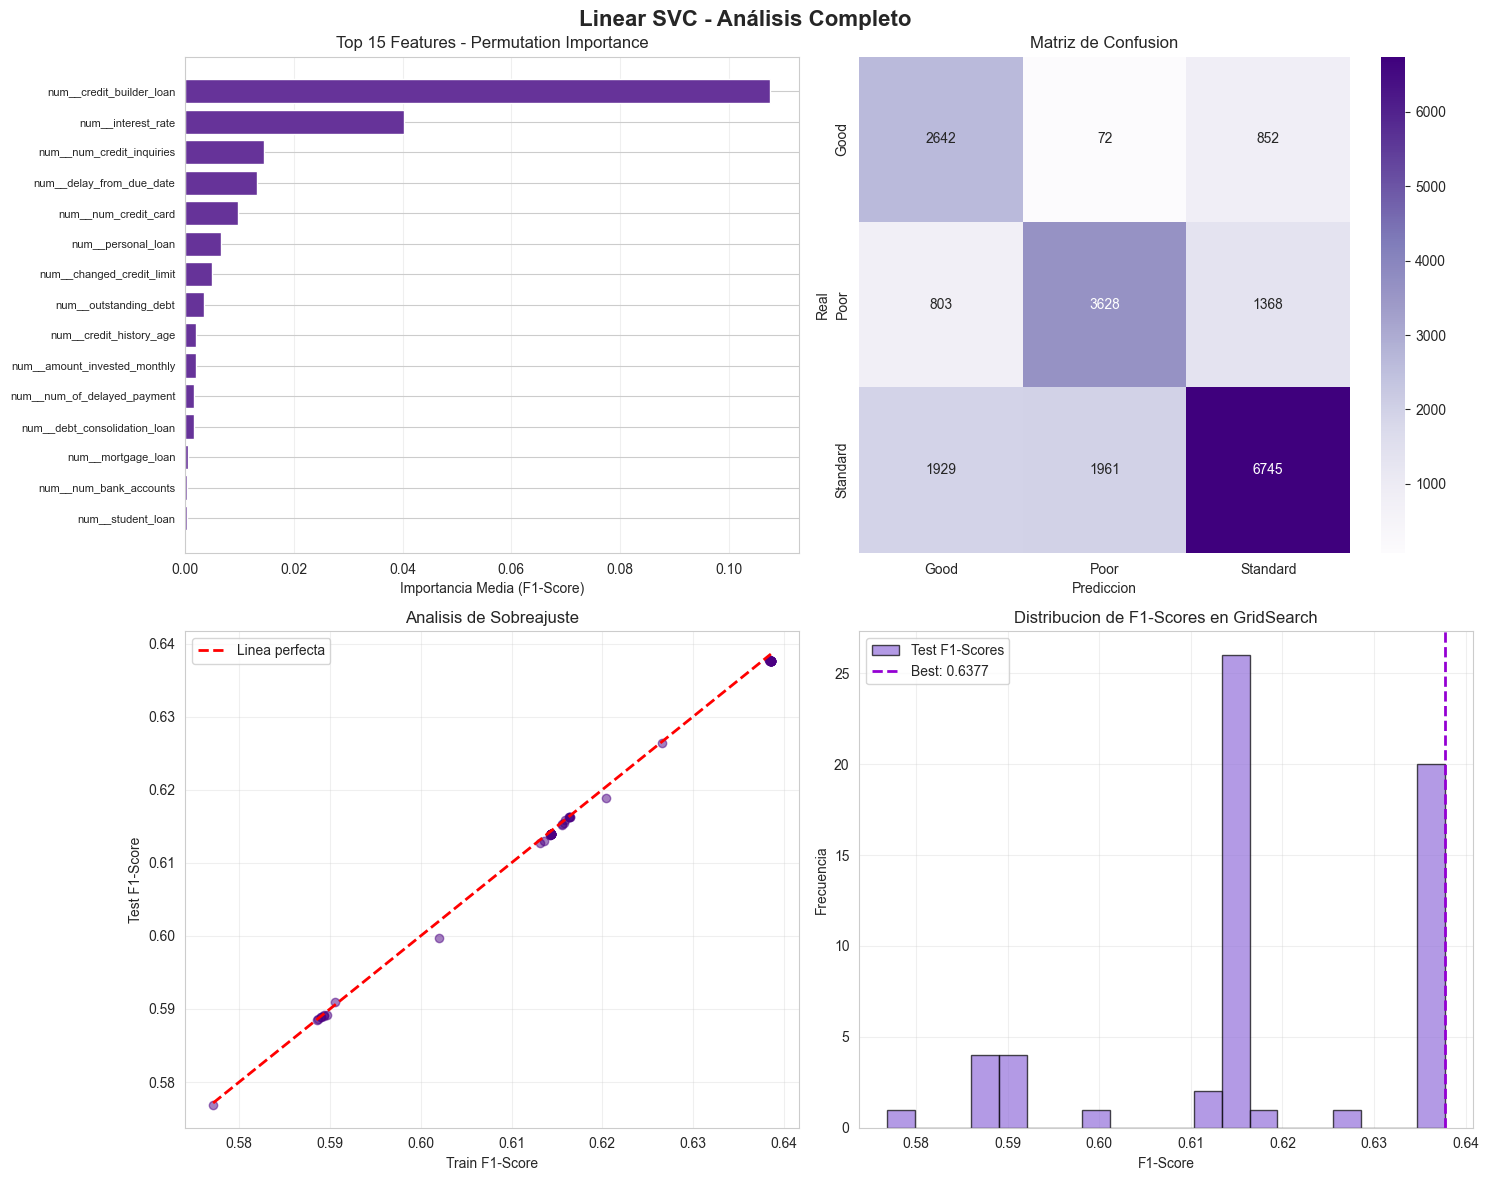

✓ Resultados completos guardados: tuning_results/Linear_SVC_results.pkl
✓ Mejor modelo guardado: tuning_results/best_Linear_SVC_model.pkl


In [44]:
# ============================================================================
# LINEAR SVC - TUNING
# ============================================================================

print("\n" + "="*80)
print("MODELO 5/5: LINEAR SVC")
print("="*80)

try:
    from sklearn.svm import LinearSVC
    from sklearn.model_selection import GridSearchCV
    from sklearn.inspection import permutation_importance
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                                 precision_score, recall_score,
                                 classification_report, confusion_matrix)

    start_time = time.time()

    # Pipeline
    svc_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LinearSVC(random_state=RANDOM_STATE, max_iter=3000, dual='auto'))
    ])

    # Grid de parámetros - separado por penalty para evitar combinaciones inválidas
    # IMPORTANTE: LinearSVC no soporta penalty='l1' con loss='hinge'
    svc_param_grid = [
        # L2 penalty con ambos loss
        {
            'classifier__penalty': ['l2'],
            'classifier__loss': ['hinge', 'squared_hinge'],
            'classifier__C': [0.01, 0.1, 1, 10, 100],
            'classifier__class_weight': [None, 'balanced'],
            'classifier__fit_intercept': [True, False]
        },
        # L1 penalty solo con squared_hinge
        {
            'classifier__penalty': ['l1'],
            'classifier__loss': ['squared_hinge'],
            'classifier__C': [0.01, 0.1, 1, 10, 100],
            'classifier__class_weight': [None, 'balanced'],
            'classifier__fit_intercept': [True, False],
            'classifier__dual': [False]  # L1 requiere dual=False
        }
    ]

    total_combinations = (2 * 5 * 2 * 2) + (1 * 5 * 2 * 2)  # L2 + L1

    print("\nHiperparametros a optimizar:")
    print("   L2 penalty: loss=[hinge, squared_hinge], C=[0.01-100]")
    print("   L1 penalty: loss=[squared_hinge], C=[0.01-100], dual=False")
    print("   class_weight: [None, balanced]")
    print("   fit_intercept: [True, False]")
    print(f"\nCombinaciones totales: {total_combinations} (combinaciones válidas)\n")

    # GridSearch
    svc_grid = GridSearchCV(
        svc_pipeline,
        svc_param_grid,
        cv=cv_strategy,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=2,
        return_train_score=True
    )

    print("Iniciando busqueda de hiperparametros...\n")
    grid_start = time.time()
    svc_grid.fit(X_train, y_train)
    grid_time = time.time() - grid_start

    print(f"\nEntrenamiento completado en {grid_time:.2f}s ({grid_time/60:.2f} min)")
    print(f"Mejor CV score (F1-Macro): {svc_grid.best_score_:.4f}")
    print(f"Mejores parametros: {svc_grid.best_params_}")

    # =========================================================================
    # ANÁLISIS DE COMPORTAMIENTO
    # =========================================================================

    print(f"\nANALIZANDO COMPORTAMIENTO DEL MODELO...")

    results_df = pd.DataFrame(svc_grid.cv_results_)
    train_scores = results_df['mean_train_score']
    test_scores = results_df['mean_test_score']
    gap = train_scores - test_scores

    print(f"\nAnalisis de sobreajuste:")
    print(f"  Diferencia promedio train-test: {gap.mean():.4f}")
    print(f"  Configuraciones probadas: {len(results_df)}")

    # =========================================================================
    # OBTENER FEATURE NAMES DEL PIPELINE ENTRENADO
    # =========================================================================

    print(f"\nOBTENIENDO NOMBRES DE FEATURES...")

    fitted_preprocessor = svc_grid.best_estimator_.named_steps['preprocessor']
    X_train_transformed = fitted_preprocessor.transform(X_train)
    X_test_transformed = fitted_preprocessor.transform(X_test)
    n_features_actual = X_train_transformed.shape[1]

    print(f"Dimensiones despues del preprocesamiento: {X_train_transformed.shape}")

    try:
        feature_names = fitted_preprocessor.get_feature_names_out()
    except:
        feature_names = [f'feature_{i}' for i in range(n_features_actual)]

    if len(feature_names) != n_features_actual:
        feature_names = list(feature_names)[:n_features_actual] if len(feature_names) > n_features_actual else \
                       list(feature_names) + [f'feature_{i}' for i in range(len(feature_names), n_features_actual)]

    # =========================================================================
    # PERMUTATION IMPORTANCE
    # =========================================================================

    print(f"\nCALCULANDO IMPORTANCIA DE FEATURES...")
    perm_start = time.time()

    perm_result = permutation_importance(
        svc_grid.best_estimator_,
        X_test,
        y_test,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scoring='f1_macro'
    )

    perm_time = time.time() - perm_start

    # Ajustar feature_names si es necesario
    if len(feature_names) != len(perm_result.importances_mean):
        if len(feature_names) < len(perm_result.importances_mean):
            feature_names = list(feature_names) + [f'feature_{i}' for i in range(len(feature_names), len(perm_result.importances_mean))]
        else:
            feature_names = list(feature_names)[:len(perm_result.importances_mean)]

    perm_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': perm_result.importances_mean,
        'importance_std': perm_result.importances_std
    }).sort_values('importance_mean', ascending=False)

    print(f"Permutation Importance calculado en {perm_time:.2f}s")

    # =========================================================================
    # VALIDACIÓN CRUZADA ADICIONAL
    # =========================================================================

    print("\nEvaluacion adicional con validacion cruzada...")
    cv_start = time.time()
    svc_cv = cross_val_score(
        svc_grid.best_estimator_,
        X_train, y_train,
        cv=cv_strategy,
        scoring='f1_macro',
        n_jobs=-1
    )
    cv_time = time.time() - cv_start

    # =========================================================================
    # PREDICCIONES Y MÉTRICAS
    # =========================================================================

    print("Generando predicciones...")
    y_pred_train = svc_grid.best_estimator_.predict(X_train)
    y_pred_test = svc_grid.best_estimator_.predict(X_test)

    train_f1 = f1_score(y_train, y_pred_train, average='macro')
    test_f1 = f1_score(y_test, y_pred_test, average='macro')
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
    test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)
    train_precision = precision_score(y_train, y_pred_train, average='macro')
    test_precision = precision_score(y_test, y_pred_test, average='macro')
    train_recall = recall_score(y_train, y_pred_train, average='macro')
    test_recall = recall_score(y_test, y_pred_test, average='macro')

    # =========================================================================
    # MOSTRAR RESUMEN CON FORMATO ESTANDARIZADO
    # =========================================================================

    end_time = time.time()
    execution_time = end_time - start_time

    # Preparar datos para print_model_summary
    metrics = {
        'train_f1_macro': train_f1,
        'test_f1_macro': test_f1,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'train_balanced_accuracy': train_bal_acc,
        'test_balanced_accuracy': test_bal_acc,
        'train_precision_macro': train_precision,
        'test_precision_macro': test_precision,
        'train_recall_macro': train_recall,
        'test_recall_macro': test_recall
    }

    times = {
        'grid_time': grid_time,
        'perm_time': perm_time,
        'cv_time': cv_time,
        'total_time': execution_time
    }

    # Llamar a la función de resumen
    print_model_summary('Linear SVC', metrics, svc_grid.best_params_, times, svc_cv)

    # =========================================================================
    # TOP 10 FEATURES MÁS IMPORTANTES
    # =========================================================================

    print("\n📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES")
    print("-" * 100)
    top10_data = {
        'Rank': range(1, 11),
        'Feature': perm_df.head(10)['feature'].values,
        'Importancia': perm_df.head(10)['importance_mean'].values,
        'Desv. Est.': perm_df.head(10)['importance_std'].values
    }
    top10_df = pd.DataFrame(top10_data)
    print(top10_df.to_string(index=False))

    print(f"\n\n📊 REPORTE DE CLASIFICACIÓN DETALLADO")
    print("-" * 100)
    print(classification_report(y_test, y_pred_test))

    # =========================================================================
    # GRÁFICAS
    # =========================================================================

    print("\nGenerando graficas...")

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Linear SVC - Análisis Completo', fontsize=16, fontweight='bold')

    # 1. Top 15 Features más importantes
    top_features = perm_df.head(15)
    axes[0, 0].barh(range(len(top_features)), top_features['importance_mean'], color='rebeccapurple')
    axes[0, 0].set_yticks(range(len(top_features)))
    axes[0, 0].set_yticklabels(top_features['feature'], fontsize=8)
    axes[0, 0].set_xlabel('Importancia Media (F1-Score)')
    axes[0, 0].set_title('Top 15 Features - Permutation Importance')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(True, alpha=0.3, axis='x')

    # 2. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred_test)
    classes = sorted(y_test.unique())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0, 1],
                xticklabels=classes, yticklabels=classes)
    axes[0, 1].set_title('Matriz de Confusion')
    axes[0, 1].set_ylabel('Real')
    axes[0, 1].set_xlabel('Prediccion')

    # 3. Train vs Test Scores
    axes[1, 0].scatter(train_scores, test_scores, alpha=0.5, color='indigo')
    axes[1, 0].plot([train_scores.min(), train_scores.max()],
                    [train_scores.min(), train_scores.max()],
                    'r--', lw=2, label='Linea perfecta')
    axes[1, 0].set_xlabel('Train F1-Score')
    axes[1, 0].set_ylabel('Test F1-Score')
    axes[1, 0].set_title('Analisis de Sobreajuste')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Distribución de scores
    axes[1, 1].hist(test_scores, bins=20, alpha=0.7, label='Test F1-Scores',
                    edgecolor='black', color='mediumpurple')
    axes[1, 1].axvline(svc_grid.best_score_, color='darkviolet', linestyle='--',
                       linewidth=2, label=f'Best: {svc_grid.best_score_:.4f}')
    axes[1, 1].set_xlabel('F1-Score')
    axes[1, 1].set_ylabel('Frecuencia')
    axes[1, 1].set_title('Distribucion de F1-Scores en GridSearch')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()

    # Guardar gráficas
    os.makedirs('tuning_results', exist_ok=True)
    plt.savefig('tuning_results/Linear_SVC_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Graficas guardadas en: tuning_results/Linear_SVC_analysis.png")
    plt.show()

    # =========================================================================
    # GUARDADO DE RESULTADOS
    # =========================================================================

    svm_results = {
        'model': svc_grid.best_estimator_,
        'model_name': 'Linear_SVC',
        'best_params': svc_grid.best_params_,
        'training_time': grid_time,
        'total_time': execution_time,
        'grid_search_results': svc_grid.cv_results_,
        'permutation_importance': perm_df,
        'feature_names': list(feature_names),
        'cv_scores': {
            'mean': svc_cv.mean(),
            'std': svc_cv.std(),
            'scores': svc_cv
        },
        'metrics': {
            'train_f1_macro': train_f1,
            'test_f1_macro': test_f1,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'train_balanced_accuracy': train_bal_acc,
            'test_balanced_accuracy': test_bal_acc,
            'train_precision_macro': train_precision,
            'test_precision_macro': test_precision,
            'train_recall_macro': train_recall,
            'test_recall_macro': test_recall
        },
        'predictions': {
            'y_train_pred': y_pred_train,
            'y_test_pred': y_pred_test
        },
        'confusion_matrix': cm,
        'classification_report': classification_report(y_test, y_pred_test),
        'overfitting_analysis': {
            'train_test_gap_mean': gap.mean(),
            'train_test_gap_std': gap.std()
        }
    }

    joblib.dump(svm_results, 'tuning_results/Linear_SVC_results.pkl')
    print("✓ Resultados completos guardados: tuning_results/Linear_SVC_results.pkl")

    joblib.dump(svc_grid.best_estimator_, 'tuning_results/best_Linear_SVC_model.pkl')
    print("✓ Mejor modelo guardado: tuning_results/best_Linear_SVC_model.pkl")

except Exception as e:
    print(f"\nERROR en Linear SVC: {e}")
    traceback.print_exc()
    svm_results = None


---
## 9. Tabla Comparativa con Hiperparámetros

In [38]:
# ============================================================================
# TABLA COMPARATIVA - F1-SCORE PRIORITARIO
# ============================================================================

print("\n" + "="*100)
print("TABLA COMPARATIVA DE TODOS LOS MODELOS (F1-Score Prioritario)")
print("="*100)

# Recopilar resultados
all_results = []
model_names = {
    'lr_results': 'Logistic Regression',
    'ridge_results': 'Ridge Classifier',
    'dt_results': 'Decision Tree',
    'nb_results': 'Gaussian Naive Bayes',
    'svm_results': 'Linear SVC'
}

print("\nEstado de modelos:")
for var_name, display_name in model_names.items():
    if var_name in globals() and globals()[var_name] is not None:
        all_results.append(globals()[var_name])
        print(f"  ✓ {display_name}")
    else:
        print(f"  ✗ {display_name}: NO DISPONIBLE")

if len(all_results) == 0:
    print("\nERROR: No hay resultados para consolidar")
else:
    print(f"\nModelos completados: {len(all_results)}/5\n")

    # Crear DataFrame base
    data = {
        'Modelo': [],
        'F1_Test': [],
        'F1_Train': [],
        'F1_CV': [],
        'Overfitting': [],
        'Accuracy_Test': [],
        'Precision_Test': [],
        'Recall_Test': [],
        'Balanced_Acc_Test': [],
        'CV_Std': [],
        'Tiempo_min': []
    }

    # Extraer métricas de cada resultado
    for result in all_results:
        data['Modelo'].append(result['model_name'])

        # Métricas de test
        metrics = result.get('metrics', {})
        data['F1_Test'].append(metrics.get('test_f1_macro', 0))
        data['F1_Train'].append(metrics.get('train_f1_macro', 0))
        data['Accuracy_Test'].append(metrics.get('test_accuracy', 0))
        data['Precision_Test'].append(metrics.get('test_precision_macro', 0))
        data['Recall_Test'].append(metrics.get('test_recall_macro', 0))
        data['Balanced_Acc_Test'].append(metrics.get('test_balanced_accuracy', 0))

        # Validación cruzada
        cv_scores = result.get('cv_scores', {})
        data['F1_CV'].append(cv_scores.get('mean', 0))
        data['CV_Std'].append(cv_scores.get('std', 0))

        # Overfitting
        train_f1 = metrics.get('train_f1_macro', 0)
        test_f1 = metrics.get('test_f1_macro', 0)
        data['Overfitting'].append(train_f1 - test_f1)

        # Tiempo
        train_time = result.get('training_time', 0)
        data['Tiempo_min'].append(train_time / 60)

    # Crear DataFrame
    summary_df = pd.DataFrame(data)

    # Ordenar por F1_Test (métrica principal) de mayor a menor
    summary_df = summary_df.sort_values('F1_Test', ascending=False).reset_index(drop=True)
    summary_df.insert(0, 'Rank', range(1, len(summary_df) + 1))

    # =========================================================================
    # TABLA 1: MÉTRICAS PRINCIPALES (F1-Score enfocado)
    # =========================================================================

    print("\n" + "="*120)
    print("📊 TABLA 1: MÉTRICAS DE RENDIMIENTO (Ordenado por F1-Score Test)")
    print("="*120 + "\n")

    # Crear tabla simplificada con métricas principales
    main_metrics_df = summary_df[['Rank', 'Modelo', 'F1_Test', 'F1_Train', 'F1_CV',
                                   'Overfitting', 'Accuracy_Test', 'Tiempo_min']].copy()

    # Formatear para mejor visualización
    pd.set_option('display.float_format', lambda x: f'{x:.4f}')
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 150)

    print(main_metrics_df.to_string(index=False))

    # =========================================================================
    # TABLA 2: MÉTRICAS DETALLADAS
    # =========================================================================

    print("\n\n" + "="*120)
    print("📊 TABLA 2: MÉTRICAS DETALLADAS")
    print("="*120 + "\n")

    detailed_df = summary_df[['Rank', 'Modelo', 'Precision_Test', 'Recall_Test',
                              'Balanced_Acc_Test', 'CV_Std']].copy()
    print(detailed_df.to_string(index=False))

    # =========================================================================
    # TOP 3 MODELOS CON DETALLES
    # =========================================================================

    print("\n\n" + "="*120)
    print("🏆 TOP 3 MODELOS (Por F1-Score Test)")
    print("="*120)

    for i in range(min(3, len(summary_df))):
        row = summary_df.iloc(i)
        model_result = all_results[i]

        print(f"\n{'='*120}")
        print(f"#{i+1}. {row['Modelo'].upper()}")
        print(f"{'='*120}")

        # Métricas principales
        print(f"\n📈 MÉTRICAS PRINCIPALES:")
        print(f"   F1-Score Test:  {row['F1_Test']:.4f} ({row['F1_Test']*100:.2f}%)")
        print(f"   F1-Score Train: {row['F1_Train']:.4f} ({row['F1_Train']*100:.2f}%)")
        print(f"   F1-Score CV:    {row['F1_CV']:.4f} ± {row['CV_Std']:.4f}")

        # Status de overfitting
        overfitting_status = "✓ Buen ajuste" if abs(row['Overfitting']) < 0.05 else \
                           "⚠ Ligero sobreajuste" if abs(row['Overfitting']) < 0.10 else \
                           "✗ Sobreajuste significativo"
        print(f"   Overfitting:    {row['Overfitting']:+.4f} ({overfitting_status})")

        print(f"\n📊 OTRAS MÉTRICAS:")
        print(f"   Accuracy:       {row['Accuracy_Test']:.4f} ({row['Accuracy_Test']*100:.2f}%)")
        print(f"   Precision:      {row['Precision_Test']:.4f} ({row['Precision_Test']*100:.2f}%)")
        print(f"   Recall:         {row['Recall_Test']:.4f} ({row['Recall_Test']*100:.2f}%)")
        print(f"   Balanced Acc:   {row['Balanced_Acc_Test']:.4f} ({row['Balanced_Acc_Test']*100:.2f}%)")

        print(f"\n⏱  EFICIENCIA:")
        print(f"   Tiempo Total:   {row['Tiempo_min']:.2f} min")

        print(f"\n⚙️  MEJORES HIPERPARÁMETROS:")
        best_params = model_result.get('best_params', {})
        for param, value in best_params.items():
            param_clean = param.replace('classifier__', '')
            print(f"   {param_clean}: {value}")

    # =========================================================================
    # ANÁLISIS COMPARATIVO
    # =========================================================================

    print("\n\n" + "="*120)
    print("📊 ANÁLISIS COMPARATIVO")
    print("="*120)

    best_model = summary_df.iloc[0]
    worst_model = summary_df.iloc[-1]

    print(f"\n🥇 MEJOR MODELO: {best_model['Modelo']}")
    print(f"   F1-Score Test: {best_model['F1_Test']:.4f} ({best_model['F1_Test']*100:.2f}%)")
    print(f"   Mejora vs peor modelo: {(best_model['F1_Test'] - worst_model['F1_Test'])*100:.2f}%")

    print(f"\n📈 ESTADÍSTICAS GENERALES:")
    print(f"   F1-Score promedio: {summary_df['F1_Test'].mean():.4f}")
    print(f"   Desv. Est. F1:     {summary_df['F1_Test'].std():.4f}")
    print(f"   Rango F1:          [{summary_df['F1_Test'].min():.4f}, {summary_df['F1_Test'].max():.4f}]")

    print(f"\n⚠️  OVERFITTING:")
    avg_overfit = summary_df['Overfitting'].mean()
    print(f"   Overfitting promedio: {avg_overfit:+.4f}")
    print(f"   Modelos bien ajustados: {len(summary_df[summary_df['Overfitting'].abs() < 0.05])} de {len(summary_df)}")

    print(f"\n⏱  EFICIENCIA COMPUTACIONAL:")
    print(f"   Tiempo promedio:  {summary_df['Tiempo_min'].mean():.2f} min")
    print(f"   Modelo más rápido: {summary_df.loc[summary_df['Tiempo_min'].idxmin(), 'Modelo']} ({summary_df['Tiempo_min'].min():.2f} min)")
    print(f"   Modelo más lento:  {summary_df.loc[summary_df['Tiempo_min'].idxmax(), 'Modelo']} ({summary_df['Tiempo_min'].max():.2f} min)")

    # =========================================================================
    # TABLA DE HIPERPARÁMETROS
    # =========================================================================

    print("\n\n" + "="*120)
    print("⚙️  TABLA DE HIPERPARÁMETROS")
    print("="*120 + "\n")

    params_data = {'Modelo': data['Modelo']}

    # Recopilar todos los hiperparámetros únicos
    all_param_names = set()
    for result in all_results:
        best_params = result.get('best_params', {})
        for param in best_params.keys():
            param_clean = param.replace('classifier__', '')
            all_param_names.add(param_clean)

    # Crear columnas para cada hiperparámetro
    for param_name in sorted(all_param_names):
        params_data[param_name] = []
        for result in all_results:
            best_params = result.get('best_params', {})
            # Buscar el parámetro (con o sin prefijo)
            value = None
            for key, val in best_params.items():
                if key.replace('classifier__', '') == param_name:
                    value = val
                    break
            params_data[param_name].append(str(value) if value is not None else '-')

    params_df = pd.DataFrame(params_data)

    # Reordenar según ranking de F1-Score
    params_df['Rank'] = summary_df['Rank'].values
    params_df = params_df.sort_values('Rank')
    params_df = params_df.drop('Rank', axis=1)

    print(params_df.to_string(index=False))

    # =========================================================================
    # GUARDAR RESULTADOS
    # =========================================================================

    print("\n\n" + "="*120)
    print("💾 GUARDANDO RESULTADOS")
    print("="*120 + "\n")

    # CSV con todas las métricas
    summary_df.to_csv('modelos_restantes_comparacion_completa.csv', index=False)
    print("   ✓ modelos_restantes_comparacion_completa.csv")

    # CSV solo con métricas principales
    main_metrics_df.to_csv('modelos_restantes_metricas_principales.csv', index=False)
    print("   ✓ modelos_restantes_metricas_principales.csv")

    # CSV con métricas detalladas
    detailed_df.to_csv('modelos_restantes_metricas_detalladas.csv', index=False)
    print("   ✓ modelos_restantes_metricas_detalladas.csv")

    # CSV con hiperparámetros
    params_df.to_csv('modelos_restantes_hiperparametros.csv', index=False)
    print("   ✓ modelos_restantes_hiperparametros.csv")

    # Resultados completos en pickle
    joblib.dump(all_results, 'all_models_results.pkl', compress=3)
    print("   ✓ all_models_results.pkl")

    print("\n" + "="*120)
    print("✓ ANÁLISIS COMPARATIVO COMPLETADO")
    print("="*120)



TABLA COMPARATIVA DE TODOS LOS MODELOS (F1-Score Prioritario)

Estado de modelos:
  ✓ Logistic Regression
  ✓ Ridge Classifier
  ✓ Decision Tree
  ✓ Gaussian Naive Bayes
  ✓ Linear SVC

Modelos completados: 5/5


📊 TABLA 1: MÉTRICAS DE RENDIMIENTO (Ordenado por F1-Score Test)

 Rank               Modelo  F1_Test  F1_Train  F1_CV  Overfitting  Accuracy_Test  Tiempo_min
    1        Decision_Tree   0.6789    0.6810 0.6790       0.0021         0.7019      2.1681
    2  Logistic_Regression   0.6417    0.6417 0.6418      -0.0001         0.6484     15.9518
    3           Linear_SVC   0.6372    0.6390 0.6387       0.0018         0.6501     35.1127
    4     Ridge_Classifier   0.6346    0.6347 0.6344       0.0001         0.6396      2.9961
    5 Gaussian_Naive_Bayes   0.6264    0.6272 0.6269       0.0008         0.6298      0.6096


📊 TABLA 2: MÉTRICAS DETALLADAS

 Rank               Modelo  Precision_Test  Recall_Test  Balanced_Acc_Test  CV_Std
    1        Decision_Tree          0.6797    

TypeError: Cannot index by location index with a non-integer key

---
## 10. Visualizaciones

In [ ]:
# ============================================================================
# VISUALIZACIONES COMPARATIVAS - F1-SCORE PRIORITARIO
# ============================================================================

if len(all_results) > 0:
    print("\n" + "="*100)
    print("Generando visualizaciones comparativas...")
    print("="*100)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Comparación de Modelos - F1-Score Prioritario',
                 fontsize=18, fontweight='bold', y=0.995)

    # Ordenar por F1-Score Test
    sorted_indices = summary_df.sort_values('F1_Test', ascending=True).index
    sorted_models = summary_df.loc[sorted_indices, 'Modelo']
    sorted_f1_test = summary_df.loc[sorted_indices, 'F1_Test']
    sorted_f1_cv = summary_df.loc[sorted_indices, 'F1_CV']
    sorted_cv_std = summary_df.loc[sorted_indices, 'CV_Std']
    sorted_accuracy = summary_df.loc[sorted_indices, 'Accuracy_Test']
    sorted_time = summary_df.loc[sorted_indices, 'Tiempo_min']

    # Colores diferenciados
    colors_f1 = plt.cm.RdYlGn(sorted_f1_test / sorted_f1_test.max())

    # 1. F1-Score Test (PRIORITARIO)
    bars1 = axes[0, 0].barh(sorted_models, sorted_f1_test, color=colors_f1, edgecolor='black', linewidth=1.2)
    axes[0, 0].set_xlabel('F1-Score', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('⭐ F1-Score Test (Métrica Principal)', fontsize=13, fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3, linestyle='--')
    axes[0, 0].set_xlim([sorted_f1_test.min() * 0.95, sorted_f1_test.max() * 1.05])

    # Agregar valores en las barras
    for i, (bar, val) in enumerate(zip(bars1, sorted_f1_test)):
        axes[0, 0].text(val, i, f' {val:.4f}',
                       va='center', fontweight='bold', fontsize=10)

    # 2. F1-Score Cross-Validation con barras de error
    bars2 = axes[0, 1].barh(sorted_models, sorted_f1_cv,
                           xerr=sorted_cv_std,
                           color='mediumseagreen',
                           edgecolor='darkgreen',
                           linewidth=1.2,
                           capsize=5,
                           alpha=0.8)
    axes[0, 1].set_xlabel('F1-Score CV', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('🎯 Cross-Validation F1-Score (5-Folds)', fontsize=13, fontweight='bold')
    axes[0, 1].grid(axis='x', alpha=0.3, linestyle='--')

    # Agregar valores
    for i, (val, std) in enumerate(zip(sorted_f1_cv, sorted_cv_std)):
        axes[0, 1].text(val, i, f' {val:.4f}±{std:.4f}',
                       va='center', fontsize=9)

    # 3. Accuracy Test (métrica secundaria)
    colors_acc = plt.cm.Blues(sorted_accuracy / sorted_accuracy.max())
    bars3 = axes[1, 0].barh(sorted_models, sorted_accuracy,
                           color=colors_acc,
                           edgecolor='navy',
                           linewidth=1.2)
    axes[1, 0].set_xlabel('Accuracy', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('📊 Accuracy Test (Métrica Secundaria)', fontsize=13, fontweight='bold')
    axes[1, 0].grid(axis='x', alpha=0.3, linestyle='--')

    # Agregar valores
    for i, (bar, val) in enumerate(zip(bars3, sorted_accuracy)):
        axes[1, 0].text(val, i, f' {val:.4f}',
                       va='center', fontsize=10)

    # 4. Tiempo de Entrenamiento
    colors_time = plt.cm.YlOrRd(sorted_time / sorted_time.max())
    bars4 = axes[1, 1].barh(sorted_models, sorted_time,
                           color=colors_time,
                           edgecolor='darkred',
                           linewidth=1.2)
    axes[1, 1].set_xlabel('Tiempo (minutos)', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('⏱️ Tiempo de Entrenamiento', fontsize=13, fontweight='bold')
    axes[1, 1].grid(axis='x', alpha=0.3, linestyle='--')

    # Agregar valores
    for i, (bar, val) in enumerate(zip(bars4, sorted_time)):
        axes[1, 1].text(val, i, f' {val:.2f} min',
                       va='center', fontsize=10)

    # Ajustar layout
    plt.tight_layout()

    # Guardar
    plt.savefig('modelos_comparacion_graficos.png', dpi=300, bbox_inches='tight')
    print("\n✓ Graficos guardados: modelos_comparacion_graficos.png")
    plt.show()

    # =========================================================================
    # GRÁFICO ADICIONAL: F1-Score Train vs Test (Overfitting Analysis)
    # =========================================================================

    print("\nGenerando grafico de analisis de overfitting...")

    fig2, ax = plt.subplots(1, 1, figsize=(12, 8))

    # Preparar datos
    models_list = summary_df['Modelo'].values
    f1_train_list = summary_df['F1_Train'].values
    f1_test_list = summary_df['F1_Test'].values
    overfitting_list = summary_df['Overfitting'].values

    x = np.arange(len(models_list))
    width = 0.35

    # Crear barras
    bars_train = ax.bar(x - width/2, f1_train_list, width,
                       label='F1-Score Train',
                       color='skyblue',
                       edgecolor='navy',
                       linewidth=1.2)
    bars_test = ax.bar(x + width/2, f1_test_list, width,
                      label='F1-Score Test',
                      color='lightcoral',
                      edgecolor='darkred',
                      linewidth=1.2)

    # Configurar gráfico
    ax.set_xlabel('Modelos', fontsize=13, fontweight='bold')
    ax.set_ylabel('F1-Score', fontsize=13, fontweight='bold')
    ax.set_title('Análisis de Overfitting: F1-Score Train vs Test',
                fontsize=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=45, ha='right')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Agregar valores y gap
    for i, (train_val, test_val, overfit) in enumerate(zip(f1_train_list, f1_test_list, overfitting_list)):
        # Valor train
        ax.text(i - width/2, train_val, f'{train_val:.3f}',
               ha='center', va='bottom', fontsize=9, fontweight='bold')
        # Valor test
        ax.text(i + width/2, test_val, f'{test_val:.3f}',
               ha='center', va='bottom', fontsize=9, fontweight='bold')
        # Gap
        gap_y = (train_val + test_val) / 2
        gap_color = 'green' if abs(overfit) < 0.05 else 'orange' if abs(overfit) < 0.10 else 'red'
        ax.text(i, gap_y, f'Δ{overfit:+.3f}',
               ha='center', va='center', fontsize=9,
               bbox=dict(boxstyle='round,pad=0.3', facecolor=gap_color, alpha=0.3))

    plt.tight_layout()
    plt.savefig('modelos_overfitting_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Graficos guardados: modelos_overfitting_analysis.png")
    plt.show()

    print("\n" + "="*100)
    print("✓ VISUALIZACIONES COMPLETADAS")
    print("="*100)

else:
    print("\n⚠️  No hay datos para visualizar")


---
## 11. Conclusiones

### ✅ Modelos Optimizados
1. Logistic Regression (L1, L2, ElasticNet)
2. Ridge Classifier (L2)
3. Decision Tree Classifier
4. Gaussian Naive Bayes
5. Linear SVC

### 📊 Metodología
- **Pipeline**: Preprocesamiento + Modelo
- **GridSearchCV**: Búsqueda exhaustiva
- **StratifiedKFold**: 5 folds
- **Métricas**: Accuracy, Precision, Recall, F1 (macro)

### 📁 Archivos Generados
**Modelos (.pkl)**
- logistic_regression_tuned.pkl
- ridge_classifier_tuned.pkl
- decision_tree_tuned.pkl
- gaussian_naive_bayes_tuned.pkl
- linear_svc_tuned.pkl

**Resultados**
- modelos_restantes_comparacion_completa.csv (con hiperparámetros)
- modelos_restantes_metricas.csv (solo métricas)
- all_models_results.pkl (resultados detallados)
- modelos_comparacion_graficos.png

### 🎯 Próximos Pasos
1. Comparar con XGBoost, Random Forest, KNN optimizados
2. Seleccionar TOP 3 modelos (F1-Score + CV estabilidad)
3. Aplicar interpretabilidad (SHAP, Feature Importance)
4. Validación final y deployment

---
## 9. Tabla Comparativa con Hiperparámetros

In [ ]:
# ============================================================================
# TABLA COMPARATIVA CON HIPERPARÁMETROS INCLUIDOS
# ============================================================================

print("
" + "="*100)
print("GENERANDO TABLA COMPARATIVA")
print("="*100)

# Recopilar resultados
all_results = []
for r in [lr_results, ridge_results, dt_results, nb_results, svm_results]:
    if r is not None:
        all_results.append(r)

if len(all_results) == 0:
    print("ERROR: No hay resultados para consolidar")
else:
    print(f"
Modelos completados: {len(all_results)}/5
")
    
    # Crear DataFrame base
    data = {
        'Modelo': [r['model_name'] for r in all_results],
        'Test_F1': [r['test_f1'] for r in all_results],
        'Test_Accuracy': [r['test_accuracy'] for r in all_results],
        'Test_Precision': [r['test_precision'] for r in all_results],
        'Test_Recall': [r['test_recall'] for r in all_results],
        'CV_Mean': [r['cv_mean'] for r in all_results],
        'CV_Std': [r['cv_std'] for r in all_results],
        'Overfit_F1': [r['overfit_f1'] for r in all_results],
        'Train_Time_s': [r['training_time'] for r in all_results]
    }
    
    # Agregar hiperparámetros como columnas
    for result in all_results:
        if result['best_params_clean']:
            for param, value in result['best_params_clean'].items():
                col_name = f"HP_{param}"
                if col_name not in data:
                    data[col_name] = [None] * len(all_results)
                idx = [r['model_name'] for r in all_results].index(result['model_name'])
                data[col_name][idx] = value
    
    # DataFrame
    summary_df = pd.DataFrame(data)
    summary_df = summary_df.sort_values('Test_F1', ascending=False).reset_index(drop=True)
    summary_df.insert(0, 'Rank', range(1, len(summary_df) + 1))
    
    # Mostrar
    print("
" + "="*150)
    print("TABLA COMPARATIVA - MODELOS CON HIPERPARAMETROS")
    print("="*150 + "
")
    
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 200)
    pd.set_option('display.float_format', lambda x: f'{x:.4f}')
    
    print(summary_df.to_string(index=False))
    
    # TOP 3
    print("

TOP 3 MODELOS:")
    print("="*80)
    for i in range(min(3, len(summary_df))):
        row = summary_df.iloc[i]
        print(f"
{i+1}. {row['Modelo']}")
        print(f"   F1: {row['Test_F1']:.4f} | CV: {row['CV_Mean']:.4f}+/-{row['CV_Std']:.4f}")
        print(f"   Acc: {row['Test_Accuracy']:.4f} | Time: {row['Train_Time_s']:.1f}s")
    
    # Guardar
    print("

GUARDANDO RESULTADOS:")
    summary_df.to_csv('modelos_restantes_comparacion_completa.csv', index=False)
    print("   >> modelos_restantes_comparacion_completa.csv (con hiperparámetros)")
    
    metrics_cols = ['Rank', 'Modelo', 'Test_F1', 'Test_Accuracy', 'CV_Mean', 'CV_Std', 'Train_Time_s']
    summary_df[metrics_cols].to_csv('modelos_restantes_metricas.csv', index=False)
    print("   >> modelos_restantes_metricas.csv (solo métricas)")
    
    joblib.dump(all_results, 'all_models_results.pkl', compress=3)
    print("   >> all_models_results.pkl (resultados completos)")
    
    print("
" + "="*100)
    print("ANALISIS COMPLETADO")
    print("="*100)

---
## 10. Visualizaciones

In [ ]:
# ============================================================================
# VISUALIZACIONES COMPARATIVAS
# ============================================================================

if len(all_results) > 0:
    print("
Generando visualizaciones...")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Comparacion de Modelos Optimizados', fontsize=16, fontweight='bold')
    
    # F1-Score
    axes[0, 0].barh(summary_df['Modelo'], summary_df['Test_F1'], color='steelblue')
    axes[0, 0].set_xlabel('F1-Score')
    axes[0, 0].set_title('Test F1-Score')
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # Accuracy
    axes[0, 1].barh(summary_df['Modelo'], summary_df['Test_Accuracy'], color='coral')
    axes[0, 1].set_xlabel('Accuracy')
    axes[0, 1].set_title('Test Accuracy')
    axes[0, 1].grid(axis='x', alpha=0.3)
    
    # CV
    axes[1, 0].barh(summary_df['Modelo'], summary_df['CV_Mean'], 
                    xerr=summary_df['CV_Std'], color='mediumseagreen', capsize=5)
    axes[1, 0].set_xlabel('F1-Score')
    axes[1, 0].set_title('Cross-Validation (Mean +/- Std)')
    axes[1, 0].grid(axis='x', alpha=0.3)
    
    # Training Time
    axes[1, 1].barh(summary_df['Modelo'], summary_df['Train_Time_s']/60, color='mediumpurple')
    axes[1, 1].set_xlabel('Tiempo (minutos)')
    axes[1, 1].set_title('Tiempo de Entrenamiento')
    axes[1, 1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('modelos_comparacion_graficos.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(">> modelos_comparacion_graficos.png guardado")
else:
    print("No hay datos para visualizar")

---
## 11. Conclusiones

### Modelos Optimizados
1. Logistic Regression (L1, L2, ElasticNet)
2. Ridge Classifier (L2)
3. Decision Tree Classifier
4. Gaussian Naive Bayes
5. Linear SVC

### Metodologia
- **Pipeline**: Preprocesamiento + Modelo
- **GridSearchCV**: Busqueda exhaustiva
- **StratifiedKFold**: 5 folds
- **Metricas**: Accuracy, Precision, Recall, F1 (macro)

### Archivos Generados
**Modelos (.pkl)**
- logistic_regression_tuned.pkl
- ridge_classifier_tuned.pkl
- decision_tree_tuned.pkl
- gaussian_naive_bayes_tuned.pkl
- linear_svc_tuned.pkl

**Resultados**
- modelos_restantes_comparacion_completa.csv (con hiperparametros)
- modelos_restantes_metricas.csv (solo metricas)
- all_models_results.pkl (resultados detallados)
- modelos_comparacion_graficos.png

### Proximos Pasos
1. Comparar con XGBoost, Random Forest, KNN optimizados
2. Seleccionar TOP 3 modelos (F1-Score + CV estabilidad)
3. Aplicar interpretabilidad (SHAP, Feature Importance)
4. Validacion final y deployment